# Allocation de portefeuille crypto — de la théorie à la vérité empirique
### Étude complète : sélection, pondération, timing — sur univers large, par régime de marché

---

**Objectif.** Répondre, chiffres et graphiques à l'appui, à une question simple : *comment allouer un capital
sur des cryptos, et qu'est-ce qui marche vraiment ?* On teste **toutes** les grandes méthodes de pondération
(Equal-weight, Inverse-vol, Min-Variance, Risk-Parity, HRP, Max-Sharpe/momentum, Drift), on les compare à des
**benchmarks** (buy & hold BTC, buy & hold du meilleur actif), on étudie l'effet de la **fréquence de
rebalancement**, et — surtout — on ne juge **jamais sur un seul panier** : on regarde la **distribution** sur
des centaines de combinaisons, **séparément en Consolidation et en Bull**.

**Le fil rouge — les 3 décisions.** Toute allocation se décompose en trois choix *indépendants* :

$$
\underbrace{\text{SÉLECTION}}_{\text{quels coins ?}}
\quad\Longrightarrow\quad
\underbrace{\text{PONDÉRATION}}_{\text{combien de chacun ?}}
\quad\Longrightarrow\quad
\underbrace{\text{TIMING}}_{\text{quand entrer / sortir ?}}
$$

On montrera lequel **domine** (spoiler : ce n'est pas celui qu'on croit).

> ⚠️ **Honnêteté méthodologique.** Un backtest est une *description du passé*, pas une prédiction. On travaille
> sur **un seul cycle** (2022-2026) et un univers limité — donc on distingue soigneusement ce qui est
> **robuste** (vrai sur des centaines de paniers, sur des plateaux de paramètres) de ce qui est du **bruit**
> (vrai sur un panier chanceux, un pic de paramètre). Tout est **net de coûts de transaction**.

## Table des matières

**I. Théorie & problème** — objectif, les 3 décisions, maths, Markowitz, coûts & rebalancement
**II. Données & régimes** — univers large, détection Bear / Consolidation / Bull
**III. Les méthodes** — implémentation + formule de chacune
**IV. Benchmark & comparaisons** — méthodes vs hold BTC vs hold meilleure crypto ; étude de fréquence ; drift vs rebalance
**V. Analyse par distribution** — 495 paniers, par régime, Top-10/Bottom-10, quels coins choisir
**VI. Robustesse des paramètres** — plateaux vs pics (détection d'overfitting)
**VII. Simulation 4 000 €** — richesse finale, timing de sortie, opérationnel
**VIII. Synthèse honnête** — ce qui est robuste, ce qui est du bruit, recommandation

# PARTIE I — Théorie & problème

## 1. Le problème
On dispose d'un capital $V_0$ à répartir sur $N$ actifs. À chaque instant, un vecteur de poids
$w=(w_1,\dots,w_N)$, $w_i\ge 0$ (long-only), $\sum_i w_i \le 1$ (le reste en cash). Le rendement du
portefeuille sur une période est
$$ r_p = \sum_i w_i\, r_i = w^\top r . $$
On veut maximiser la **richesse finale** $V_T = V_0\prod_t (1+r_{p,t})$ tout en maîtrisant le **risque**.

## 2. Les deux mesures qui comptent
**Ratio de Sharpe** (performance ajustée du risque) :
$$ \text{SR} = \frac{\mathbb{E}[r_p]-r_f}{\sqrt{\text{Var}(r_p)}}\times\sqrt{A} $$
($A$ = facteur d'annualisation ; crypto 24/7 ⇒ $A=365$). **Drawdown maximal** (pire perte depuis un sommet) :
$$ \text{MaxDD} = \min_t \left(\frac{V_t}{\max_{s\le t}V_s}-1\right). $$

## 3. Markowitz et pourquoi il est fragile
La théorie moderne (Markowitz 1952) dit : choisir $w$ pour maximiser $\dfrac{w^\top\mu}{\sqrt{w^\top\Sigma w}}$,
où $\mu$ = rendements espérés, $\Sigma$ = matrice de covariance. **Problème** : on ne connaît ni $\mu$ ni
$\Sigma$, on les *estime* — et l'optimiseur est un **amplificateur d'erreur d'estimation**. Il surpondère
précisément les actifs dont on a *surestimé* le rendement. D'où des méthodes plus robustes qui s'appuient
surtout sur $\Sigma$ (mieux estimable que $\mu$) : Risk-Parity, HRP, Min-Variance.

## 4. Coûts de transaction & rebalancement
À chaque rebalancement, tourner le portefeuille coûte. Turnover $\text{TO}=\sum_i|w_{i,t}-w_{i,t^-}|$, coût
$\text{TC}=(f+s)\cdot\text{TO}$ ($f$=frais, $s$=spread). Deux forces opposées gouvernent le rebalancement :
- **Le « rebalancing bonus »** (récolte de volatilité) : rebalancer vend ce qui a monté / rachète ce qui a
  baissé ⇒ « vend haut, achète bas ». **Gagne quand les actifs se ressemblent / mean-revert.**
- **Le momentum / laisser-courir** : ne pas rebalancer laisse gonfler le gagnant. **Gagne quand UN actif
  explose.** Mais rebalancer *trop souvent* fait **whipsawer** le momentum (le court terme reverse).

On mesurera **empiriquement** ces deux forces.

# PARTIE II — Données & régimes de marché

In [1]:
%matplotlib inline
import os, warnings, itertools
import numpy as np, pandas as pd
import scipy.optimize as sco
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (12, 4.6), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
RNG = np.random.default_rng(42)


def find_csv():
    for c in ("data_raw/broad_daily_close_current.csv", "../data_raw/broad_daily_close_current.csv"):
        if os.path.exists(c):
            return c
    raise FileNotFoundError("broad_daily_close_current.csv introuvable")


PXf = pd.read_csv(find_csv(), index_col=0, parse_dates=True).dropna(how="any")
ANNUAL = 365
print(f"Univers : {PXf.shape[1]} cryptos | {PXf.shape[0]} jours | {PXf.index[0].date()} → {PXf.index[-1].date()}")
print("Actifs :", ", ".join(c[:-4] for c in PXf.columns))

R_all = PXf.pct_change().fillna(0.0)
mkt = (1 + R_all.mean(axis=1)).cumprod()            # indice de marché équipondéré

Univers : 37 cryptos | 1661 jours | 2022-01-01 → 2026-07-19
Actifs : BTC, ETH, BNB, SOL, XRP, ADA, DOGE, AVAX, LINK, DOT, LTC, TRX, ATOM, UNI, ETC, XLM, NEAR, ALGO, FIL, VET, ICP, HBAR, AAVE, THETA, AXS, SAND, MANA, GRT, CHZ, ENJ, ZEC, EGLD, XTZ, IOTA, KAVA, ZIL, QTUM


## Détection des régimes : Bear / Consolidation / Bull

On classe **chaque jour** selon la tendance de l'indice de marché (équipondéré des 37 cryptos) :
- **Bull** 🟢 : forte tendance haussière — rendement 90 j $>+25\%$ **et** marché au-dessus de sa moyenne 100 j.
- **Bear** 🔴 : marché sous sa moyenne 100 j **et** rendement 90 j $<-10\%$.
- **Consolidation** 🟡 : le reste (range / accumulation / early recovery).

On mesurera ensuite chaque stratégie **séparément dans chaque régime**.

Répartition des jours par régime :
   bull           : 18.2 %
   consolidation  : 36.7 %
   bear           : 45.1 %


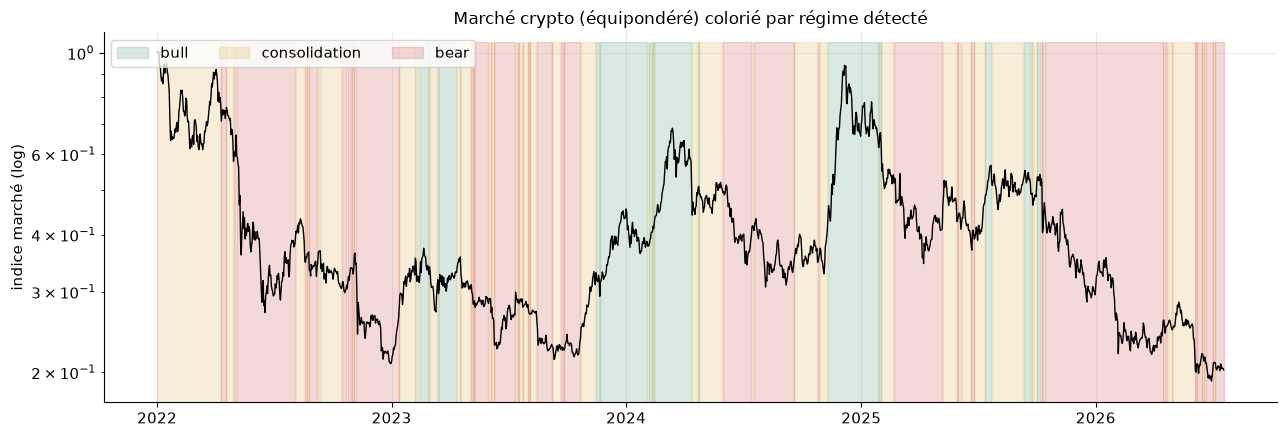


Phase Consolidation+Bull principale : 2022-12-31 → 2024-12-06 (marché ×4.5)


In [2]:
ret90 = mkt.pct_change(90)
ma100 = mkt.rolling(100).mean()
regime = np.where((ret90 > 0.25) & (mkt > ma100), "bull",
          np.where((mkt < ma100) & (ret90 < -0.10), "bear", "consolidation"))
regime = pd.Series(regime, index=mkt.index)
REG = regime.values
print("Répartition des jours par régime :")
for rg in ["bull", "consolidation", "bear"]:
    print(f"   {rg:14s} : {(regime == rg).mean() * 100:.1f} %")

fig, ax = plt.subplots(figsize=(13, 4.5))
colors = {"bull": "#2f855a", "consolidation": "#d69e2e", "bear": "#c53030"}
ax.plot(mkt.index, mkt.values, color="black", lw=1)
for rg, col in colors.items():
    ax.fill_between(mkt.index, 0, mkt.values.max() * 1.05, where=(regime == rg).values,
                    color=col, alpha=0.18, step="mid", label=rg)
ax.set_yscale("log"); ax.set_ylabel("indice marché (log)")
ax.set_title("Marché crypto (équipondéré) colorié par régime détecté", fontsize=12)
ax.legend(ncol=3, loc="upper left"); ax.set_ylim(mkt.min() * 0.9, mkt.max() * 1.1)
plt.tight_layout(); plt.show()

# fenêtres consolidation+bull (du creux du bear au sommet du bull) pour les analyses "phase haussière"
trough = mkt.iloc[:550].idxmin(); peak = mkt.loc[trough:].idxmax()
TP, PK = PXf.index.get_loc(trough), PXf.index.get_loc(peak)
print(f"\nPhase Consolidation+Bull principale : {trough.date()} → {peak.date()} "
      f"(marché ×{mkt.loc[peak]/mkt.loc[trough]:.1f})")

### Structure de corrélation de l'univers
Les cryptos sont **très corrélées** entre elles (tout monte/descend ensemble) — c'est pourquoi la
diversification par pondération apporte peu, et pourquoi la **sélection** (choisir les leaders) compte tant.

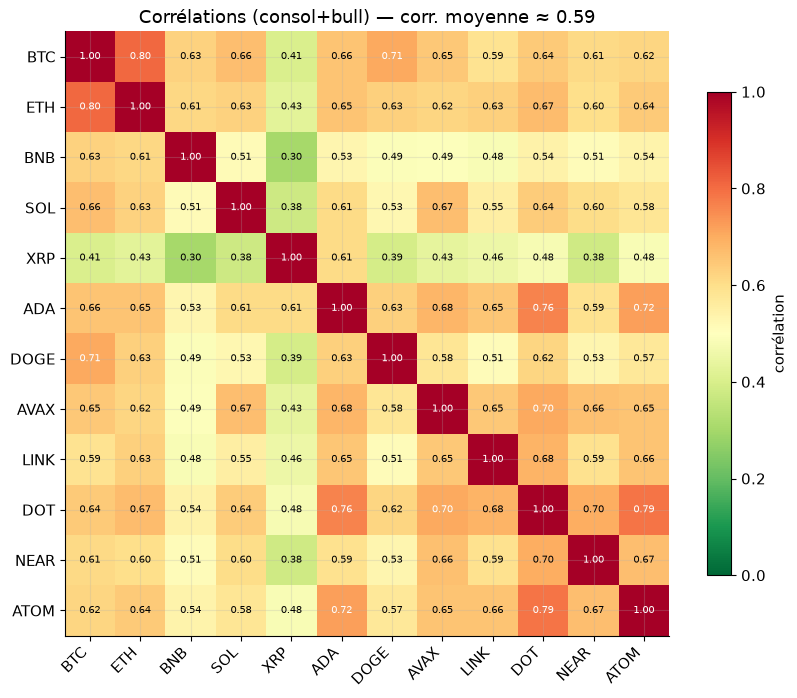

In [3]:
MAJORS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT",
          "DOGEUSDT", "AVAXUSDT", "LINKUSDT", "DOTUSDT", "NEARUSDT", "ATOMUSDT"]
corr = R_all.loc[trough:peak, MAJORS].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="RdYlGn_r")
ax.set_xticks(range(len(MAJORS))); ax.set_yticks(range(len(MAJORS)))
labs = [a[:-4] for a in MAJORS]
ax.set_xticklabels(labs, rotation=45, ha="right"); ax.set_yticklabels(labs)
for i in range(len(MAJORS)):
    for j in range(len(MAJORS)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if corr.values[i, j] > 0.7 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="corrélation")
ax.set_title(f"Corrélations (consol+bull) — corr. moyenne ≈ {(corr.values[np.triu_indices(len(MAJORS),1)]).mean():.2f}")
plt.tight_layout(); plt.show()

# PARTIE III — Les méthodes de pondération (+ formule)

On implémente **from scratch** (numpy/scipy) :

| Méthode | Idée | Utilise |
|---|---|---|
| **Equal-weight** | $w_i=1/N$ | rien |
| **Inverse-vol** | $w_i\propto 1/\sigma_i$ | volatilités |
| **Min-Variance** | $\min_w w^\top\Sigma w$ | $\Sigma$ |
| **Risk-Parity** | contributions au risque égales | $\Sigma$ |
| **HRP** | clustering hiérarchique + bissection | corrélations |
| **Max-Sharpe** | $\max_w \frac{w^\top\mu}{\sqrt{w^\top\Sigma w}}$, $\mu$=momentum | $\mu,\Sigma$ |
| **Drift** | acheter 1/N et **ne jamais** rebalancer | rien |

La covariance est estimée par **shrinkage de Ledoit-Wolf** (bien conditionnée), $\mu$ par le **momentum**
(rendement des 90 derniers jours).

### Les deux ingrédients communs : $\hat\Sigma$ et $\hat\mu$

**Covariance $\hat\Sigma$ — shrinkage de Ledoit-Wolf.** La covariance empirique $S$ est bruitée et mal
conditionnée (son inverse amplifie le bruit). On la « rétrécit » vers une cible structurée $F$ (identité mise
à l'échelle) :
$$ \hat\Sigma = \delta\,F + (1-\delta)\,S, \qquad \delta\in[0,1] $$
où $\delta$ est choisi pour **minimiser l'erreur d'estimation attendue** (formule close de Ledoit-Wolf 2004).
Plus l'échantillon est court/bruité, plus $\delta\to 1$ (on fait confiance à la structure).

**Rendements espérés $\hat\mu$ — momentum.** On ne prédit pas vraiment : on utilise le **momentum**, la
régularité empirique la plus robuste — $\hat\mu_i = P_{i,t}/P_{i,t-90}-1$ (rendement des 90 derniers jours).
« Ce qui monte tend à continuer à monter » (à horizon mois, pas semaine).

---

### 1. Equal-weight (équipondéré) — $w_i = 1/N$
**Intuition** : répartir également, aucune vue. Le benchmark naïf.
**Force** : zéro estimation → zéro erreur d'estimation. Célèbre pour être **difficile à battre** (DeMiguel,
Garlappi & Uppal 2009, *« Optimal versus naive diversification »*). **Faiblesse** : ignore risque et
corrélations. **Verdict empirique (ce notebook)** : excellente médiane, **jamais catastrophique** → le choix robuste.

### 2. Inverse-volatilité — $w_i \propto 1/\sigma_i$
**Intuition** : donner moins de poids aux actifs les plus agités. **Force** : simple, réduit le risque, pas
besoin des corrélations. **Faiblesse** : ignore les corrélations et **sous-pondère les gagnants volatils**.
**Verdict** : proche de l'equal-weight, un peu moins bien en bull crypto (il fuit SOL, justement le gagnant).

### 3. Min-Variance — $\min_w\; w^\top\Sigma w$ s.c. $\mathbf 1^\top w=1,\ w\ge0$
**Intuition** : le portefeuille de **plus faible risque possible**, sans aucune vue sur le rendement.
**Comment** : nécessite d'inverser $\Sigma$ (via l'optimiseur). **Force** : minimise la volatilité.
**Faiblesse** : se **concentre** sur les actifs peu volatils, **très sensible aux erreurs** d'estimation de
$\Sigma$. **Verdict** : en bull crypto, il fuit le gagnant volatil → **le pire des risk-based**.

### 4. Risk-Parity — contributions au risque égales
**Intuition** : que chaque actif contribue **également au risque total** (pas également en capital). La
contribution au risque de l'actif $i$ est
$$ \text{RC}_i = \frac{w_i\,(\Sigma w)_i}{\sqrt{w^\top\Sigma w}}, \qquad \text{on cherche } \text{RC}_i = \text{RC}_j\ \forall i,j. $$
**Force** : plus équilibré que min-var (ne mise pas tout sur le moins volatil) ; standard des fonds
*« all-weather »* (Bridgewater). **Faiblesse** : toujours risk-based → sous-pondère le gagnant. **Verdict** :
proche de l'equal-weight.

### 5. HRP — *Hierarchical Risk Parity* (López de Prado 2016)
**Intuition** : **contourner l'inversion de $\Sigma$** (source d'instabilité) en exploitant la *structure* de
corrélation, en **3 étapes** :
1. **Clustering hiérarchique** : distance $d_{ij}=\sqrt{\tfrac12(1-\rho_{ij})}$, puis arbre d'agrégation
   (les actifs qui bougent ensemble sont regroupés).
2. **Quasi-diagonalisation** : réordonner la matrice pour que les actifs similaires soient adjacents.
3. **Bissection récursive** : descendre l'arbre en répartissant le budget de risque entre les deux
   sous-groupes **inversement à leur variance**.
**Force** : robuste (jamais d'inversion), diversifié, **brille avec beaucoup d'actifs**. **Faiblesse** :
risk-based → sous-pondère le gagnant ; peu d'intérêt sur 4 actifs très corrélés. **Verdict** : correct, pas gagnant en bull.

### 6. Max-Sharpe (tangence, piloté par le momentum) — $\max_w \dfrac{w^\top\mu}{\sqrt{w^\top\Sigma w}}$
**Intuition** : le portefeuille au **meilleur rapport rendement/risque** ex-ante. Ici $\mu$ = momentum → il
**concentre sur le coin au plus fort momentum**. **Force** : capte les gagnants — **meilleure médiane ET plus
haut plafond** sur la distribution (Partie V). **Faiblesse** : **fragile aux erreurs sur $\mu$** (amplificateur
d'erreur de Markowitz), **haute variance**, et se fait **whipsawer** si rebalancé trop souvent (Partie IV.2).
**Verdict** : le meilleur en distribution, mais variable → à traiter comme un pari agressif.

### 7. Drift (buy & hold équipondéré) — acheter $1/N$ et **ne jamais** rebalancer
**Intuition** : on laisse les poids **dériver** → le gagnant gonfle tout seul (momentum *gratuit*, cf. les
stackplots en IV.4). **Force** : **zéro coût, zéro effort**. **Faiblesse** : c'est un **pari concentré
déguisé** (finit dominé par un seul coin) ; si ce coin s'effondre, le drift devient le pire. **Verdict** :
gagne **si** le panier contient un monstre (SOL) ; sinon le rebalance gagne.

> **Non implémentées ici** (mais détaillées dans le notebook compagnon *Portfolio_Allocation_Study*) :
> **Black-Litterman** (mélange bayésien d'un a priori d'équilibre et de tes « vues ») et **Robuste/Michaud**
> (resampling pour intégrer l'incertitude sur $\mu$). Sur 4 actifs, elles ne battaient pas le simple non plus.

In [4]:
N = 4
FEE = 0.0015            # 15 bps par unité de turnover (frais + spread)
LB = 120               # fenêtre d'estimation de la covariance
LMOM = 90              # lookback momentum
WARM = 210             # chauffe
END = len(PXf) - 1
_SLSQP = {"maxiter": 60, "ftol": 1e-8}


def ledoit_wolf(returns):
    """Shrinkage de Ledoit-Wolf vers l'identité mise à l'échelle (covariance bien conditionnée)."""
    X = np.asarray(returns, float); X = X - X.mean(0, keepdims=True)
    T, n = X.shape; S = (X.T @ X) / T; mu = np.trace(S) / n
    d2 = np.sum((S - mu * np.eye(n)) ** 2)
    norm2 = np.sum(X ** 2, axis=1)
    b2 = (np.sum(norm2 ** 2) - 2 * np.sum(np.einsum("ki,ij,kj->k", X, S, X)) + T * np.sum(S ** 2)) / T ** 2
    delta = 0.0 if d2 <= 0 else min(b2, d2) / d2
    return delta * mu * np.eye(n) + (1 - delta) * S


def _clean(w):
    w = np.clip(np.asarray(w, float), 0, None)
    return w / w.sum() if w.sum() > 1e-12 else np.ones(len(w)) / len(w)


def w_equal(cov, mom): return np.ones(N) / N
def w_invvol(cov, mom):
    iv = 1 / np.sqrt(np.diag(cov)); return iv / iv.sum()
def w_minvar(cov, mom):
    r = sco.minimize(lambda w: w @ cov @ w, np.ones(N) / N, method="SLSQP", bounds=[(0, 1)] * N,
                     options=_SLSQP, constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return _clean(r.x)
def w_riskparity(cov, mom):
    def obj(w):
        w = np.abs(w) + 1e-12; pv = w @ cov @ w
        return np.sum((w * (cov @ w) / pv - 1 / N) ** 2)
    r = sco.minimize(obj, np.ones(N) / N, method="SLSQP", bounds=[(1e-6, 1)] * N,
                     options={"maxiter": 200}, constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return _clean(r.x)
def w_maxsharpe(cov, mom):
    if mom is None or (mom <= 0).all(): return w_minvar(cov, mom)
    r = sco.minimize(lambda w: -(w @ mom) / (np.sqrt(w @ cov @ w) + 1e-9), np.ones(N) / N, method="SLSQP",
                     bounds=[(0, 1)] * N, options=_SLSQP, constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return _clean(r.x) if (r.x @ mom) > 0 else w_minvar(cov, mom)
def w_hrp(cov, mom):
    d = np.sqrt(np.clip(0.5 * (1 - cov / np.outer(np.sqrt(np.diag(cov)), np.sqrt(np.diag(cov)))), 0, None))
    L = linkage(squareform(d, checks=False), "single").astype(int); order = list(L[-1, :2])
    while max(order) >= N:
        nw = []
        for v in order: nw.extend([v] if v < N else [L[v - N, 0], L[v - N, 1]])
        order = nw
    w = np.ones(N); clusters = [order]
    while clusters:
        clusters = [c[s] for c in clusters for s in (slice(0, len(c) // 2), slice(len(c) // 2, None)) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            a, b = clusters[i], clusters[i + 1]
            va = 1 / np.diag(cov[np.ix_(a, a)]); va /= va.sum(); v0 = va @ cov[np.ix_(a, a)] @ va
            vb = 1 / np.diag(cov[np.ix_(b, b)]); vb /= vb.sum(); v1 = vb @ cov[np.ix_(b, b)] @ vb
            al = 1 - v0 / (v0 + v1)
            for k in a: w[k] *= al
            for k in b: w[k] *= (1 - al)
    return _clean(w)


METHODS = {"Equal": w_equal, "InvVol": w_invvol, "MinVar": w_minvar,
           "RiskPar": w_riskparity, "HRP": w_hrp, "MaxSharpe": w_maxsharpe}
print("Méthodes de pondération :", ", ".join(METHODS), "+ Drift (buy&hold)")

Méthodes de pondération : Equal, InvVol, MinVar, RiskPar, HRP, MaxSharpe + Drift (buy&hold)


# PARTIE IV — Benchmark & comparaisons (illustratif sur 1 panier)

On prend un panier représentatif de 4 cryptos et on compare **toutes les méthodes** entre elles et aux
**benchmarks** : *hold BTC* et *hold la meilleure crypto du panier*. Tout net de coûts, rebalancement mensuel.

> ⚠️ **À lire absolument.** Cette partie (et la Partie VII / 4 000 €) utilise **UN SEUL panier** (démo) — c'est
> un **exemple illustratif**, PAS le verdict. Sur ce panier précis, le momentum (Max-Sharpe) se fait
> whipsawer et finit **dernier** — alors que sur la **distribution de 495 paniers (Partie V)**, il a la
> **meilleure médiane**. Ce n'est pas une contradiction : c'est sa **haute variance** (meilleur en moyenne,
> mais sur un panier donné il peut finir premier *ou* dernier). **La règle d'or du notebook : on juge sur la
> distribution (Partie V), jamais sur un seul panier.**

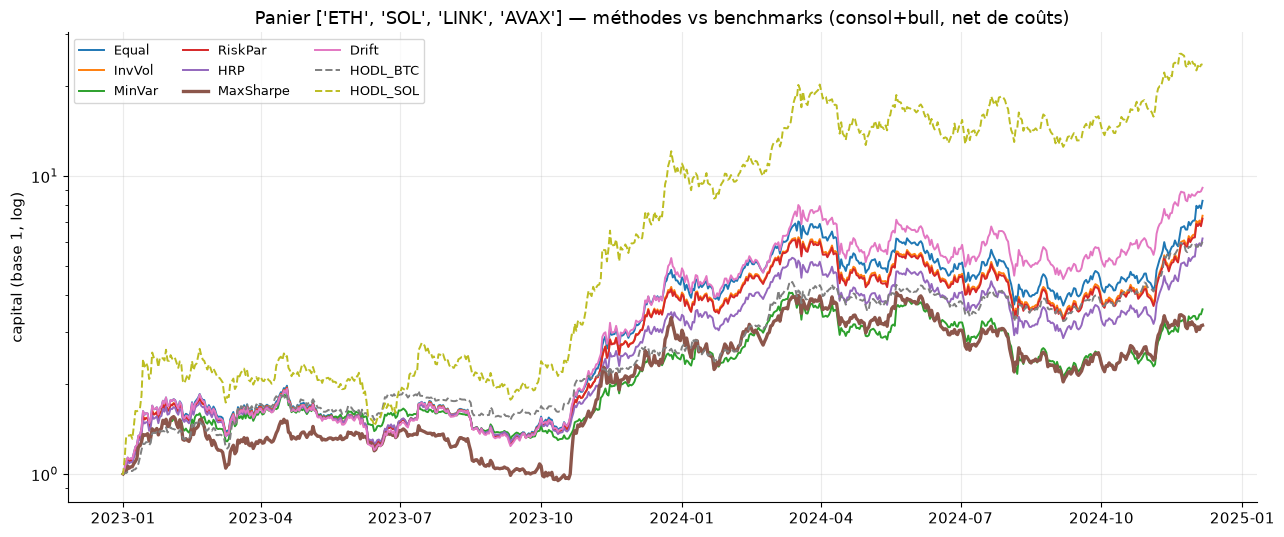

Performance (consol+bull) :
           mult   cagr  sharpe  maxdd
HODL_SOL   23.8  414.0    2.23  -45.0
Drift       9.1  214.0    1.96  -44.0
Equal       8.3  198.0    1.94  -48.0
InvVol      7.4  181.0    1.90  -47.0
RiskPar     7.2  178.0    1.89  -47.0
HRP         6.2  156.0    1.81  -46.0
HODL_BTC    6.0  153.0    2.14  -26.0
MinVar      3.6   93.0    1.43  -48.0
MaxSharpe   3.2   81.0    1.20  -50.0


In [5]:
DEMO = ["ETHUSDT", "SOLUSDT", "LINKUSDT", "AVAXUSDT"]
cols_all = list(PXf.columns)
RA = PXf.pct_change().fillna(0.0).values
PA = PXf.values
BTCv = PXf["BTCUSDT"].values


def equity_fullinvest(idx, method_fn, step=30, start=WARM, end=END):
    """Suivi € (fully invested), rebalancement calendaire, coûts réels. Renvoie la série d'équité."""
    R = RA[:, idx]; P = PA[:, idx]; pos = list(range(start, end, step))
    hold = np.zeros(N); cash = 1.0; eq = {}
    for k, p in enumerate(pos):
        tot = hold.sum() + cash
        cov = ledoit_wolf(R[max(0, p - LB):p]); mom = P[p] / P[p - LMOM] - 1
        w = method_fn(cov, mom)
        tgt = w * tot; cash = tot - tgt.sum() - FEE * np.abs(tgt - hold).sum(); hold = tgt
        nx = pos[k + 1] if k + 1 < len(pos) else end
        for t in range(p + 1, nx + 1):
            hold = hold * (1 + R[t]); eq[PXf.index[t]] = hold.sum() + cash
    return pd.Series(eq)


def equity_drift(idx, start=WARM, end=END):
    R = RA[:, idx]; hold = np.ones(N) / N; eq = {}
    for t in range(start + 1, end + 1):
        hold = hold * (1 + R[t]); eq[PXf.index[t]] = hold.sum()
    return pd.Series(eq)


# filtre de tendance : investi seulement quand le marché est au-dessus de sa MA100 (sinon cash)
regON = (mkt.values > mkt.rolling(100).mean().values)


def equity_filtered(idx, method_fn, step=30, lmom=LMOM, start=WARM, end=END):
    """Momentum + FILTRE DE TENDANCE (cash quand marché < MA100), cycle complet."""
    R = RA[:, idx]; P = PA[:, idx]; pos = list(range(start, end, step))
    hold = np.zeros(N); cash = 1.0; eq = {}
    for k, p in enumerate(pos):
        tot = hold.sum() + cash
        w = method_fn(ledoit_wolf(R[max(0, p - LB):p]), P[p] / P[p - lmom] - 1) if regON[p] else np.zeros(N)
        tgt = w * tot; cash = tot - tgt.sum() - FEE * np.abs(tgt - hold).sum(); hold = tgt
        nx = pos[k + 1] if k + 1 < len(pos) else end
        for t in range(p + 1, nx + 1):
            hold = hold * (1 + R[t]); eq[PXf.index[t]] = hold.sum() + cash
    return pd.Series(eq)


def metrics(eq):
    r = eq.pct_change().dropna(); n = len(r)
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (ANNUAL / n) - 1
    sh = r.mean() / (r.std() + 1e-12) * np.sqrt(ANNUAL)
    dd = (eq / eq.cummax() - 1).min()
    return dict(mult=eq.iloc[-1] / eq.iloc[0], cagr=cagr, sharpe=sh, maxdd=dd)


def run_with_weights(idx, method_fn, step=30, start=None, end=None):
    """Comme equity_fullinvest mais enregistre les POIDS journaliers et le turnover par rebalancement."""
    start = WARM if start is None else start; end = END if end is None else end
    R = RA[:, idx]; P = PA[:, idx]; pos = list(range(start, end, step))
    hold = np.zeros(N); cash = 1.0; eq = {}; wrec = {}; turn = {}
    names = [cols_all[i][:-4] for i in idx]
    for k, p in enumerate(pos):
        tot = hold.sum() + cash
        w = method_fn(ledoit_wolf(R[max(0, p - LB):p]), P[p] / P[p - LMOM] - 1)
        tgt = w * tot; turn[PXf.index[p]] = np.abs(tgt - hold).sum() / tot
        cash = tot - tgt.sum() - FEE * np.abs(tgt - hold).sum(); hold = tgt
        nx = pos[k + 1] if k + 1 < len(pos) else end
        for t in range(p + 1, nx + 1):
            hold = hold * (1 + R[t]); v = hold.sum() + cash
            wrec[PXf.index[t]] = hold / v; eq[PXf.index[t]] = v
    return pd.Series(eq), pd.DataFrame(wrec, index=names).T, pd.Series(turn)


def run_drift_weights(idx, start=None, end=None):
    start = WARM if start is None else start; end = END if end is None else end
    R = RA[:, idx]; hold = np.ones(N) / N; wrec = {}; eq = {}
    names = [cols_all[i][:-4] for i in idx]
    for t in range(start + 1, end + 1):
        hold = hold * (1 + R[t]); v = hold.sum(); wrec[PXf.index[t]] = hold / v; eq[PXf.index[t]] = v
    return pd.Series(eq), pd.DataFrame(wrec, index=names).T


didx = [cols_all.index(a) for a in DEMO]
sl = slice(TP, PK)   # consolidation+bull
curves = {m: equity_fullinvest(didx, fn, 30, TP, PK) for m, fn in METHODS.items()}
curves["Drift"] = equity_drift(didx, TP, PK)
# benchmarks
best_coin = DEMO[int(np.argmax([PXf[a].values[PK] / PXf[a].values[TP] for a in DEMO]))]
curves["HODL_BTC"] = pd.Series(BTCv[TP:PK + 1] / BTCv[TP], index=PXf.index[TP:PK + 1])
curves[f"HODL_{best_coin[:-4]}"] = pd.Series(PXf[best_coin].values[TP:PK + 1] / PXf[best_coin].values[TP],
                                             index=PXf.index[TP:PK + 1])

fig, ax = plt.subplots(figsize=(13, 5.5))
for name, eq in curves.items():
    st = "--" if name.startswith("HODL") else "-"
    lw = 2.4 if name == "MaxSharpe" else 1.4
    ax.plot(eq.index, eq.values, st, lw=lw, label=name)
ax.set_yscale("log"); ax.set_title(f"Panier {[a[:-4] for a in DEMO]} — méthodes vs benchmarks (consol+bull, net de coûts)")
ax.set_ylabel("capital (base 1, log)"); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

tbl = pd.DataFrame({name: metrics(eq) for name, eq in curves.items()}).T
tbl = tbl.sort_values("mult", ascending=False)
print("Performance (consol+bull) :")
print((tbl.assign(mult=tbl["mult"].round(1), cagr=(tbl["cagr"] * 100).round(0),
                  sharpe=tbl["sharpe"].round(2), maxdd=(tbl["maxdd"] * 100).round(0))).to_string())

## IV.2 — L'étude de la FRÉQUENCE de rebalancement (la falaise du whipsaw)

Ici on ajoute la 3ᵉ décision — le **TIMING** : Max-Sharpe momentum **+ filtre de tendance** (on n'est investi
que quand le marché est au-dessus de sa MA100, sinon cash), sur le **cycle complet**. On teste **hebdo (7j),
bi-hebdo (14j), mensuel (30j), 45j, 60j**. Attention — l'effet est **brutalement non-monotone**.

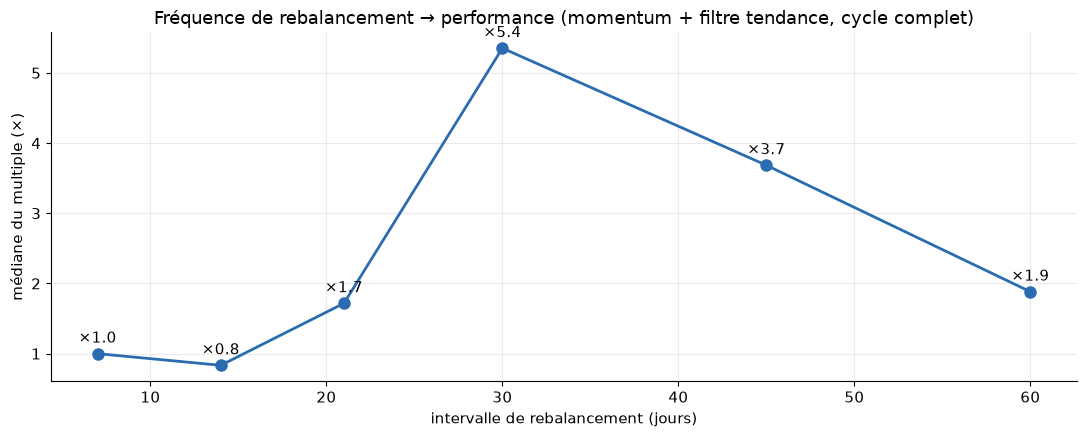

Médiane du multiple par fréquence : {'7j': np.float64(1.0), '14j': np.float64(0.8), '21j': np.float64(1.7), '30j': np.float64(5.4), '45j': np.float64(3.7), '60j': np.float64(1.9)}
→ Avec un filtre de tendance, rebalancer trop souvent (hebdo/bi-hebdo) le fait WHIPSAWER (le marché
  croise sa MA sans arrêt → on vend le dip, rachète le rebond). Le mensuel/45j est le bon compromis.


In [6]:
U12 = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT",
       "AVAXUSDT", "LINKUSDT", "DOTUSDT", "NEARUSDT", "ATOMUSDT"]
U12i = [cols_all.index(a) for a in U12]
ALL_COMBOS = [list(c) for c in itertools.combinations(U12i, 4)]           # 495 combos
SAMPLE = ALL_COMBOS[::5]                                                  # ~99 pour les balayages
freqs = [7, 14, 21, 30, 45, 60]
freq_res = {f: np.array([equity_filtered(idx, w_maxsharpe, f).iloc[-1] for idx in SAMPLE]) for f in freqs}

fig, ax = plt.subplots(figsize=(11, 4.5))
med = [np.median(freq_res[f]) for f in freqs]
ax.plot(freqs, med, "o-", color="#2b6cb0", lw=2, ms=8)
for f, m in zip(freqs, med): ax.annotate(f"×{m:.1f}", (f, m), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_xlabel("intervalle de rebalancement (jours)"); ax.set_ylabel("médiane du multiple (×)")
ax.set_title("Fréquence de rebalancement → performance (momentum + filtre tendance, cycle complet)")
plt.tight_layout(); plt.show()
print("Médiane du multiple par fréquence :", {f"{f}j": round(np.median(freq_res[f]), 1) for f in freqs})
print("→ Avec un filtre de tendance, rebalancer trop souvent (hebdo/bi-hebdo) le fait WHIPSAWER (le marché")
print("  croise sa MA sans arrêt → on vend le dip, rachète le rebond). Le mensuel/45j est le bon compromis.")

## IV.3 — Drift vs Rebalance : ça dépend du panier

**Le drift gagne** quand UN coin explose (on le laisse gonfler). **Le rebalance gagne** quand les rendements
se ressemblent (on récolte le va-et-vient). Illustration sur deux paniers.

In [7]:
for basket in (["BNBUSDT", "ETHUSDT", "LINKUSDT", "SOLUSDT"], ["BNBUSDT", "ETHUSDT", "LINKUSDT", "AVAXUSDT"]):
    bi = [cols_all.index(a) for a in basket]
    d = equity_drift(bi, TP, PK).iloc[-1]
    rb = equity_fullinvest(bi, w_equal, 30, TP, PK).iloc[-1]
    mults = {a[:-4]: PXf[a].values[PK] / PXf[a].values[TP] for a in basket}
    win = "DRIFT" if d > rb else "REBALANCE"
    print(f"{[a[:-4] for a in basket]}  drift ×{d:.1f} | equal-rebal ×{rb:.1f} → {win} gagne "
          f"| multiples: {[f'{k}×{v:.0f}' for k, v in mults.items()]}")

['BNB', 'ETH', 'LINK', 'SOL']  drift ×8.7 | equal-rebal ×7.3 → DRIFT gagne | multiples: ['BNB×3', 'ETH×3', 'LINK×5', 'SOL×24']
['BNB', 'ETH', 'LINK', 'AVAX']  drift ×3.9 | equal-rebal ×4.7 → REBALANCE gagne | multiples: ['BNB×3', 'ETH×3', 'LINK×5', 'AVAX×5']


## IV.4 — ⭐ Comprendre les stratégies : la dynamique dans le temps

C'est *ici* qu'on **voit** ce que chaque stratégie fait vraiment. On trace l'**évolution des poids** au fil du
temps (panier démo) :
- **Drift** : les poids **dérivent** — le gagnant (SOL/le plus fort) gonfle jusqu'à dominer le portefeuille.
- **Max-Sharpe (momentum)** : **rotation** — il bascule sur le coin le plus fort du moment.
- **Equal-weight (rebal)** : reste **équilibré** — on rogne le gagnant à chaque rebalancement.

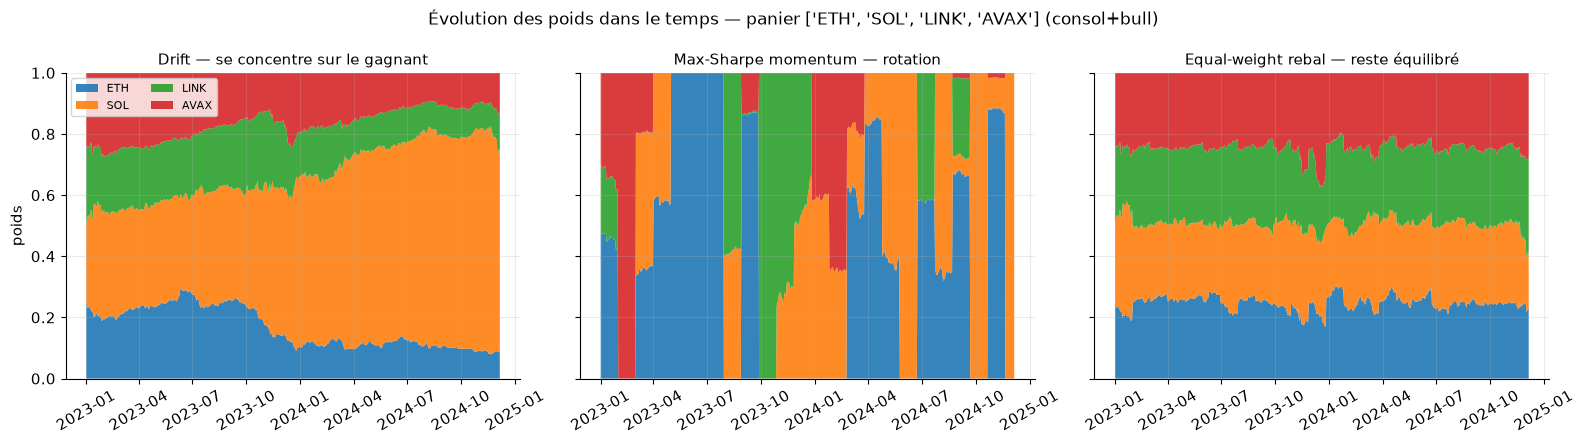

Poids finaux du DRIFT : {'ETH': 9, 'SOL': 65, 'LINK': 13, 'AVAX': 13} %  → un coin finit par dominer.


In [8]:
names_demo = [a[:-4] for a in DEMO]
colD = list(plt.cm.tab10(np.arange(N)))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
_, Wd = run_drift_weights(didx, TP, PK)
_, Wm, TOm = run_with_weights(didx, w_maxsharpe, 30, TP, PK)
_, We, TOe = run_with_weights(didx, w_equal, 30, TP, PK)
for ax, (W, ttl) in zip(axes, [(Wd, "Drift — se concentre sur le gagnant"),
                                (Wm, "Max-Sharpe momentum — rotation"),
                                (We, "Equal-weight rebal — reste équilibré")]):
    ax.stackplot(W.index, *[W[c].values for c in names_demo], colors=colD, labels=names_demo, alpha=0.9)
    ax.set_ylim(0, 1); ax.set_title(ttl, fontsize=11); ax.tick_params(axis="x", rotation=30)
axes[0].legend(loc="upper left", fontsize=8, ncol=2); axes[0].set_ylabel("poids")
fig.suptitle(f"Évolution des poids dans le temps — panier {names_demo} (consol+bull)", fontsize=12)
plt.tight_layout(); plt.show()
print(f"Poids finaux du DRIFT : {dict(zip(names_demo, (Wd.iloc[-1]*100).round(0).astype(int)))} %  "
      f"→ un coin finit par dominer.")

### Turnover (activité de trading) dans le temps
Combien chaque méthode **tourne** à chaque rebalancement. Le momentum tourne beaucoup (rotation → coûts) ;
l'equal-weight rogne juste la dérive ; le drift ne tourne jamais.

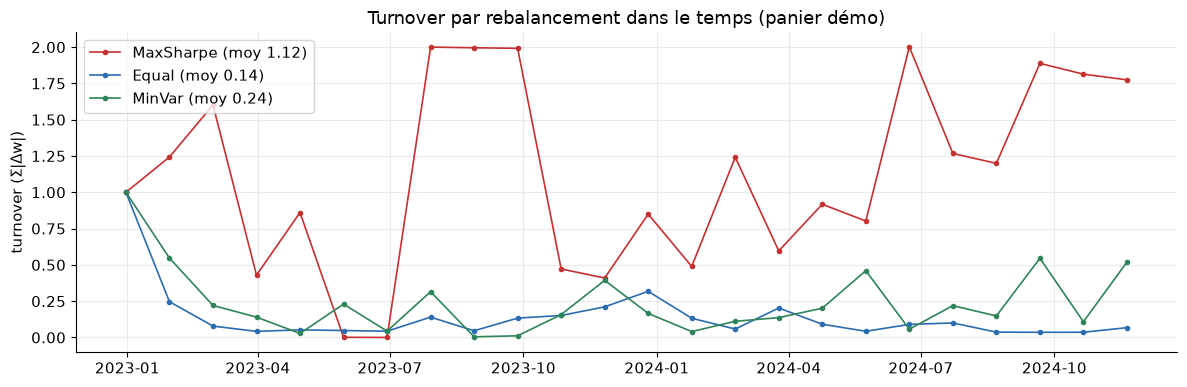

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
for m, fn, col in [("MaxSharpe", w_maxsharpe, "#c53030"), ("Equal", w_equal, "#2b6cb0"), ("MinVar", w_minvar, "#2f855a")]:
    _, _, to = run_with_weights(didx, fn, 30, TP, PK)
    ax.plot(to.index, to.values, "o-", ms=3, lw=1.2, color=col, label=f"{m} (moy {to.mean():.2f})")
ax.set_title("Turnover par rebalancement dans le temps (panier démo)"); ax.set_ylabel("turnover (Σ|Δw|)")
ax.legend(); plt.tight_layout(); plt.show()

### Courbes de drawdown (underwater) — le risque dans le temps
Combien on est « sous l'eau » (sous le dernier sommet) à chaque instant. Montre *quand* et *combien* ça fait mal.

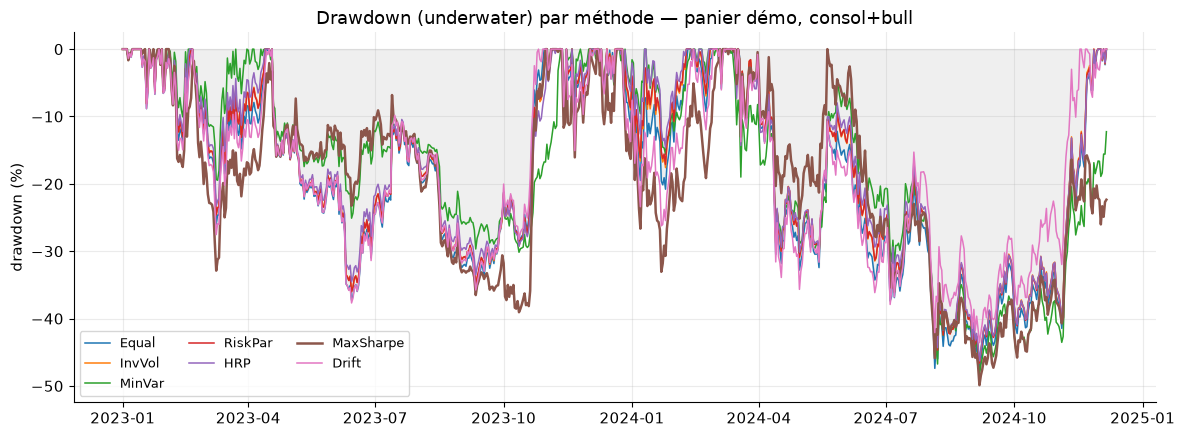

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, eq in curves.items():
    if name.startswith("HODL"):
        continue
    dd = (eq / eq.cummax() - 1) * 100
    ax.plot(dd.index, dd.values, lw=1.8 if name == "MaxSharpe" else 1.1, label=name)
ax.fill_between(curves["Equal"].index, (curves["Equal"] / curves["Equal"].cummax() - 1).values * 100, 0,
                color="grey", alpha=0.12)
ax.set_title("Drawdown (underwater) par méthode — panier démo, consol+bull")
ax.set_ylabel("drawdown (%)"); ax.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

# PARTIE V — Analyse par distribution (la bonne méthodologie)

**Un seul panier ment.** On teste chaque méthode sur **les 495 combinaisons** de 4 coins parmi 12, et on
regarde la **distribution** — séparément **en Consolidation** et **en Bull**. On calcule aussi, pour chaque
(panier, méthode), la performance compoundée **sur les jours de chaque régime**.

In [11]:
REG_ARR = REG   # régime par jour


def sim_by_regime(idx, method_fn, step=30):
    """Fully invested, rebalancement mensuel. Renvoie multiple overall + par régime (compoundé sur les jours du régime)."""
    R = RA[:, idx]; P = PA[:, idx]; pos = list(range(WARM, END, step))
    hold = np.zeros(N); cash = 1.0
    reg_mult = {"bear": 1.0, "consolidation": 1.0, "bull": 1.0}; eq = [1.0]
    for k, p in enumerate(pos):
        tot = hold.sum() + cash
        cov = ledoit_wolf(R[max(0, p - LB):p]); mom = P[p] / P[p - LMOM] - 1
        w = method_fn(cov, mom)
        tgt = w * tot; cash = tot - tgt.sum() - FEE * np.abs(tgt - hold).sum(); hold = tgt
        nx = pos[k + 1] if k + 1 < len(pos) else END
        for t in range(p + 1, nx + 1):
            v0 = hold.sum() + cash; hold = hold * (1 + R[t]); v1 = hold.sum() + cash
            rday = v1 / v0 - 1 if v0 > 0 else 0.0
            reg_mult[REG_ARR[t]] *= (1 + rday); eq.append(v1)
    eq = np.array(eq)
    sh = (np.diff(eq) / eq[:-1]).mean() / ((np.diff(eq) / eq[:-1]).std() + 1e-12) * np.sqrt(ANNUAL)
    return dict(overall=eq[-1], bull=reg_mult["bull"], consol=reg_mult["consolidation"],
                bear=reg_mult["bear"], sharpe=sh, maxdd=(eq / np.maximum.accumulate(eq) - 1).min())


print("Calcul de la distribution : 495 paniers × 7 méthodes (quelques minutes)...")
STORE = {m: [] for m in list(METHODS) + ["Drift"]}
for j, idx in enumerate(ALL_COMBOS):
    for m, fn in METHODS.items():
        STORE[m].append(sim_by_regime(idx, fn, 30))
    # drift = buy&hold équipondéré, mesuré par régime
    R = RA[:, idx]; hold = np.ones(N) / N; rmn = {"bear": 1.0, "consolidation": 1.0, "bull": 1.0}; eqd = [1.0]
    for t in range(WARM + 1, END + 1):
        v0 = hold.sum(); hold = hold * (1 + R[t]); rmn[REG_ARR[t]] *= (1 + hold.sum() / v0 - 1); eqd.append(hold.sum())
    eqd = np.array(eqd)
    STORE["Drift"].append(dict(overall=eqd[-1], bull=rmn["bull"], consol=rmn["consolidation"], bear=rmn["bear"],
                               sharpe=(np.diff(eqd) / eqd[:-1]).mean() / ((np.diff(eqd) / eqd[:-1]).std() + 1e-12) * np.sqrt(ANNUAL),
                               maxdd=(eqd / np.maximum.accumulate(eqd) - 1).min()))
print("OK.")

Calcul de la distribution : 495 paniers × 7 méthodes (quelques minutes)...


OK.


## V.1 — Distribution par méthode, séparée par régime

Pour chaque méthode : la distribution (sur 495 paniers) du multiple **en Bull** et **en Consolidation**.
On classe par médiane. **Regarde la médiane ET le pire cas, pas le meilleur.**


===== Distribution du multiple en BULL (495 paniers) =====
           moyenne   p10  mediane    p90    max
MaxSharpe     9.05  4.94     7.63  15.91  28.84
Equal         7.21  4.92     7.00   9.74  13.66
RiskPar       7.04  4.95     6.85   9.48  13.35
InvVol        6.91  4.88     6.69   9.18  12.84
HRP           6.75  4.90     6.47   8.90  12.47
Drift         6.50  4.60     6.34   8.63  11.10
MinVar        6.20  4.45     5.72   8.52  11.63

===== Distribution du multiple en CONSOLIDATION (495 paniers) =====
           moyenne   p10  mediane   p90   max
MaxSharpe     2.90  1.68     2.60  4.72  9.82
MinVar        2.03  1.44     1.99  2.65  3.48
HRP           1.96  1.50     1.95  2.41  2.98
RiskPar       1.92  1.47     1.91  2.38  2.87
InvVol        1.91  1.47     1.90  2.39  2.91
Equal         1.87  1.44     1.85  2.35  2.83
Drift         1.84  1.50     1.83  2.16  2.46


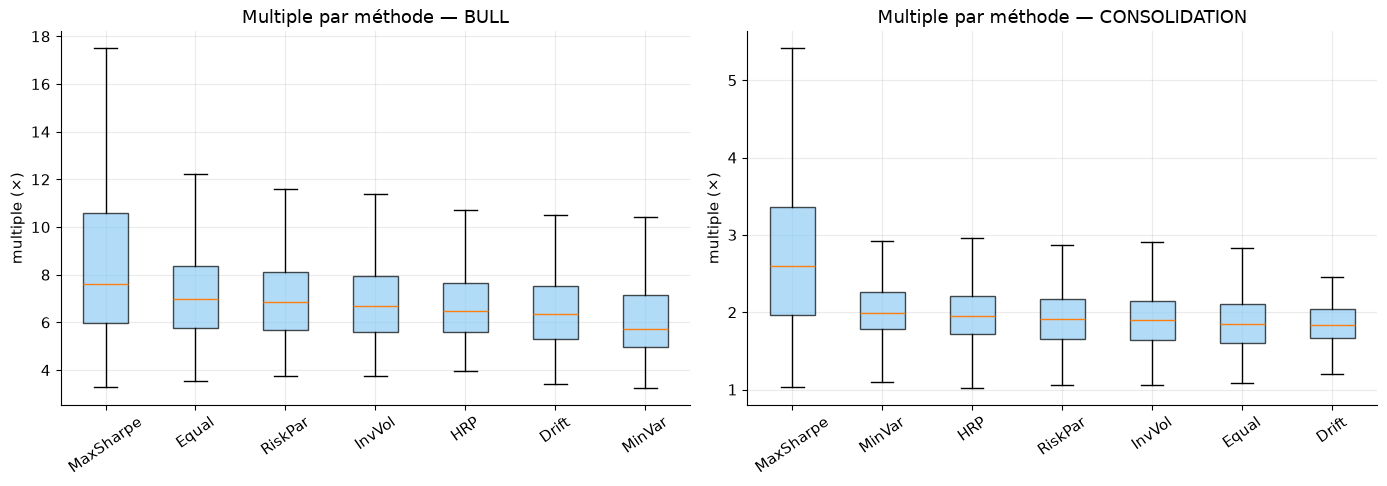

In [12]:
def dist_table(regime_key):
    rows = {}
    for m in STORE:
        a = np.array([s[regime_key] for s in STORE[m]])
        rows[m] = dict(moyenne=a.mean(), p10=np.percentile(a, 10), mediane=np.median(a),
                       p90=np.percentile(a, 90), max=a.max())
    return pd.DataFrame(rows).T.sort_values("mediane", ascending=False)


for rk, lab in [("bull", "BULL"), ("consol", "CONSOLIDATION")]:
    t = dist_table(rk)
    print(f"\n===== Distribution du multiple en {lab} (495 paniers) =====")
    print(t.round(2).to_string())

# graphique : boxplots par méthode, bull vs consolidation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (rk, lab) in zip(axes, [("bull", "BULL"), ("consol", "CONSOLIDATION")]):
    order = dist_table(rk).index.tolist()
    data = [np.array([s[rk] for s in STORE[m]]) for m in order]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, tick_labels=order)
    for patch in bp["boxes"]: patch.set_facecolor("#90cdf4"); patch.set_alpha(0.7)
    ax.set_title(f"Multiple par méthode — {lab}"); ax.set_ylabel("multiple (×)")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

## V.2 — L'effet SÉLECTION domine tout : Top-10 / Bottom-10 paniers

La méthode compte peu à côté de **quels coins tu choisis**. On classe les 495 paniers par performance
(Max-Sharpe, consol+bull) et on montre les **10 meilleurs** et **10 pires**.

🟢 TOP 10 paniers (Max-Sharpe, consol+bull) :
            panier  mult  sharpe  maxdd
  SOL+XRP+ADA+NEAR  25.5    2.32  -47.0
 SOL+XRP+DOGE+NEAR  24.4    2.25  -47.0
 SOL+XRP+AVAX+NEAR  22.0    2.20  -46.0
  SOL+XRP+DOGE+DOT  20.9    2.27  -46.0
  ETH+BNB+SOL+DOGE  20.7    2.40  -46.0
 SOL+XRP+DOGE+AVAX  20.6    2.23  -47.0
  SOL+XRP+ADA+AVAX  19.8    2.25  -43.0
 SOL+XRP+DOGE+ATOM  19.6    2.23  -48.0
  BNB+SOL+XRP+DOGE  19.5    2.33  -37.0
SOL+DOGE+AVAX+NEAR  19.3    2.11  -49.0

🔴 BOTTOM 10 paniers :
            panier  mult  sharpe  maxdd
 BNB+ADA+LINK+NEAR   2.5    1.04  -62.0
DOGE+LINK+DOT+ATOM   2.5    0.99  -65.0
 ADA+DOGE+DOT+ATOM   2.5    0.99  -63.0
BNB+LINK+NEAR+ATOM   2.4    0.99  -61.0
ADA+DOGE+LINK+ATOM   2.3    0.94  -62.0
 ADA+AVAX+DOT+ATOM   2.1    0.87  -72.0
ADA+AVAX+LINK+ATOM   2.0    0.85  -69.0
 ADA+AVAX+LINK+DOT   1.9    0.80  -65.0
 ADA+LINK+DOT+ATOM   1.8    0.79  -64.0
AVAX+LINK+DOT+ATOM   1.6    0.70  -71.0


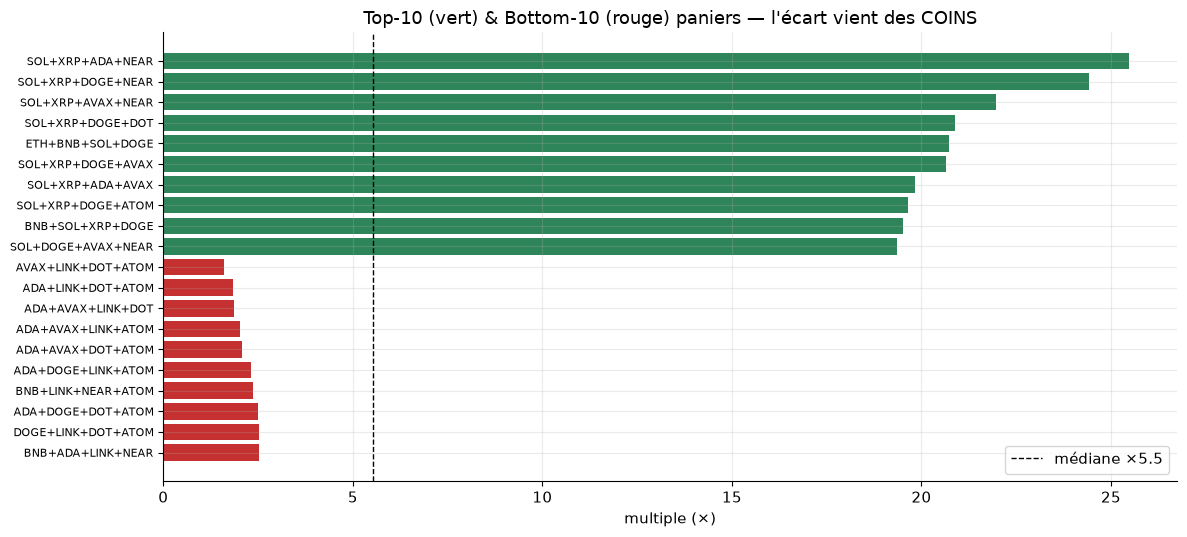

In [13]:
basket_perf = []
for idx in ALL_COMBOS:
    names = "+".join(cols_all[i][:-4] for i in idx)
    eq = equity_fullinvest(idx, w_maxsharpe, 30, TP, PK)
    basket_perf.append((names, eq.iloc[-1] / eq.iloc[0], metrics(eq)["sharpe"], metrics(eq)["maxdd"]))
bp = pd.DataFrame(basket_perf, columns=["panier", "mult", "sharpe", "maxdd"]).sort_values("mult", ascending=False)
print("🟢 TOP 10 paniers (Max-Sharpe, consol+bull) :")
print(bp.head(10).assign(mult=bp.head(10)["mult"].round(1), sharpe=bp.head(10)["sharpe"].round(2),
                         maxdd=(bp.head(10)["maxdd"] * 100).round(0)).to_string(index=False))
print("\n🔴 BOTTOM 10 paniers :")
print(bp.tail(10).assign(mult=bp.tail(10)["mult"].round(1), sharpe=bp.tail(10)["sharpe"].round(2),
                         maxdd=(bp.tail(10)["maxdd"] * 100).round(0)).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5.5))
top = bp.head(10).iloc[::-1]; bot = bp.tail(10)
allb = pd.concat([bot, top])
cols_bar = ["#c53030"] * 10 + ["#2f855a"] * 10
ax.barh(range(len(allb)), allb["mult"], color=cols_bar)
ax.set_yticks(range(len(allb))); ax.set_yticklabels(allb["panier"], fontsize=8)
ax.axvline(bp["mult"].median(), color="k", ls="--", lw=1, label=f"médiane ×{bp['mult'].median():.1f}")
ax.set_xlabel("multiple (×)"); ax.set_title("Top-10 (vert) & Bottom-10 (rouge) paniers — l'écart vient des COINS")
ax.legend(); plt.tight_layout(); plt.show()

## V.3 — ⭐ Quels coins choisir ? Leaders vs boulets

L'analyse la plus **actionnable** : pour chaque coin, sa performance solo, et à quelle fréquence il apparaît
dans le **décile supérieur** (meilleurs paniers) vs le **décile inférieur**. ⚠️ *Hindsight* : ceci décrit
2022-2024, ce n'est pas une prédiction — mais ça révèle le pattern (les coins à fort momentum ont mené).

Classement des coins (consol+bull 2022-2024) :
coin  perf_solo  pct_top  pct_bottom  verdict
 SOL       23.8     98.0        10.0 🟢 leader
DOGE        6.2     69.0        10.0 🟢 leader
 XRP        7.2     43.0         2.0 🟢 leader
NEAR        6.4     35.0        37.0 🟡 neutre
ATOM        1.1     27.0        51.0 🔴 boulet
AVAX        4.8     27.0        41.0 🔴 boulet
 ADA        5.0     24.0        33.0 🟡 neutre
 DOT        2.5     22.0        49.0 🔴 boulet
 ETH        3.3     18.0        22.0 🟡 neutre
 BTC        6.0     16.0        16.0 🟡 neutre
 BNB        3.0     16.0        63.0 🔴 boulet
LINK        4.6      4.0        65.0 🔴 boulet


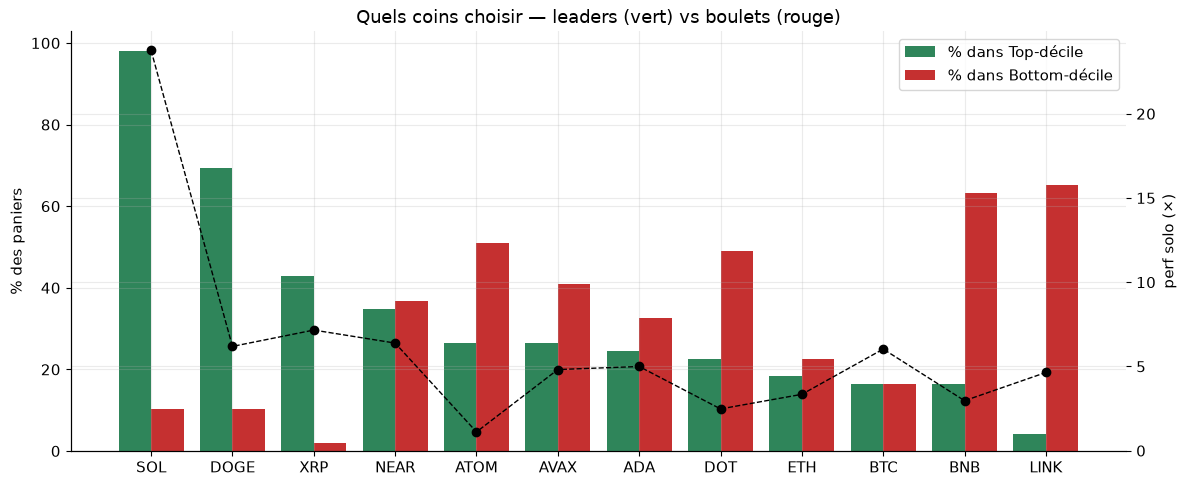

In [14]:
n_dec = len(bp) // 10
top_baskets = set(bp.head(n_dec)["panier"]); bot_baskets = set(bp.tail(n_dec)["panier"])
coin_stats = []
for a in U12:
    solo = PXf[a].values[PK] / PXf[a].values[TP]
    in_top = sum(a[:-4] in b.split("+") for b in top_baskets) / n_dec * 100
    in_bot = sum(a[:-4] in b.split("+") for b in bot_baskets) / n_dec * 100
    coin_stats.append((a[:-4], solo, in_top, in_bot))
cs = pd.DataFrame(coin_stats, columns=["coin", "perf_solo", "pct_top", "pct_bottom"]).sort_values("pct_top", ascending=False)
cs["verdict"] = np.where(cs["pct_top"] > 40, "🟢 leader", np.where(cs["pct_bottom"] > 40, "🔴 boulet", "🟡 neutre"))
print("Classement des coins (consol+bull 2022-2024) :")
print(cs.assign(perf_solo=cs["perf_solo"].round(1), pct_top=cs["pct_top"].round(0),
                pct_bottom=cs["pct_bottom"].round(0)).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cs))
ax.bar(x - 0.2, cs["pct_top"], 0.4, label="% dans Top-décile", color="#2f855a")
ax.bar(x + 0.2, cs["pct_bottom"], 0.4, label="% dans Bottom-décile", color="#c53030")
ax2 = ax.twinx(); ax2.plot(x, cs["perf_solo"], "ko--", lw=1, label="perf solo (×)")
ax.set_xticks(x); ax.set_xticklabels(cs["coin"], rotation=0); ax.set_ylabel("% des paniers")
ax2.set_ylabel("perf solo (×)"); ax.set_title("Quels coins choisir — leaders (vert) vs boulets (rouge)")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

## V.4 — ⭐ BTC mène-t-il les alts ? (lead-lag & rattrapage)

Observation de terrain : **BTC démarre souvent sa hausse AVANT les altcoins**, puis les alts « rattrapent »
(l'*alt season*). On répond à trois questions :
1. **BTC mène-t-il vraiment ?** → décalage temporel du creux et **corrélation décalée** (BTC aujourd'hui vs
   alts dans $k$ semaines).
2. **Force relative alt/BTC** → quand les alts se mettent-ils à surperformer BTC ?
3. **Nos bonnes combins montent-elles aussi vite / plus vite que BTC**, et avec quel retard au départ ?

Creux BTC : 2022-11-21  |  Creux alt-index : 2022-12-31  → BTC touche le fond 40 jours AVANT les alts
Corrélation décalée max au lag = +0 semaine(s) → synchronisé


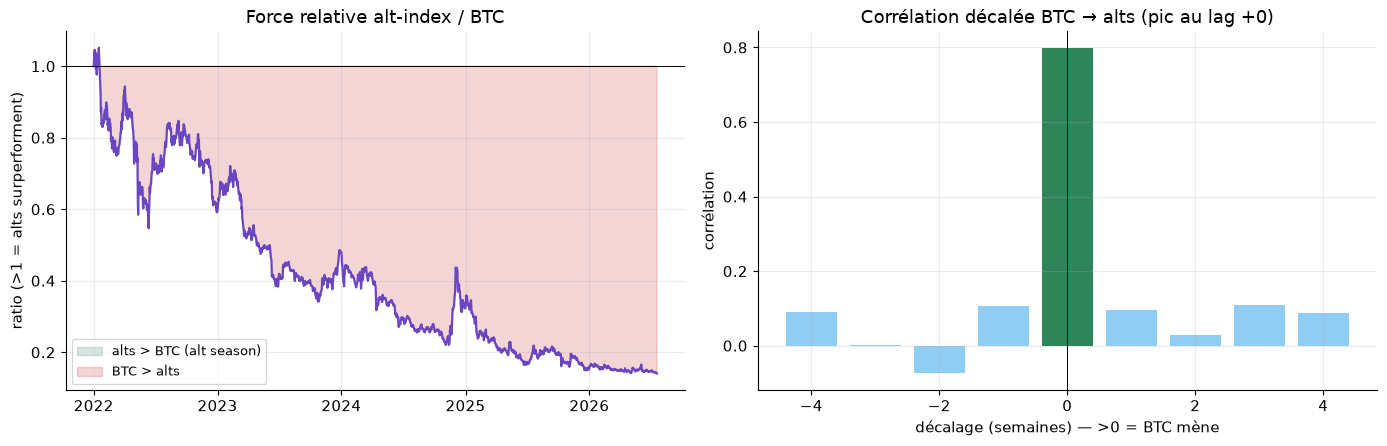

In [15]:
btc = PXf["BTCUSDT"]
alt_cols = [c for c in PXf.columns if c != "BTCUSDT"]
alt_idx = (1 + PXf[alt_cols].pct_change().fillna(0).mean(axis=1)).cumprod()

# (1) décalage des creux (qui touche le fond en premier ?)
btc_bottom = btc.loc[:"2023-06-30"].idxmin()
alt_bottom = alt_idx.loc[:"2023-06-30"].idxmin()
lead_days = (alt_bottom - btc_bottom).days

# (2) corrélation décalée (rendements hebdo)
bw = btc.resample("W").last().pct_change().dropna()
aw = alt_idx.resample("W").last().pct_change().dropna()
cmn = bw.index.intersection(aw.index); bw, aw = bw[cmn], aw[cmn]
lags = list(range(-4, 5))
xcorr = [bw.corr(aw.shift(-L)) for L in lags]      # corr(BTC_t, alt_{t+L}) ; L>0 => BTC mène
best_lag = lags[int(np.argmax(xcorr))]

print(f"Creux BTC : {btc_bottom.date()}  |  Creux alt-index : {alt_bottom.date()}  "
      f"→ BTC touche le fond {abs(lead_days)} jours {'AVANT' if lead_days>0 else 'après'} les alts")
print(f"Corrélation décalée max au lag = {best_lag:+d} semaine(s) "
      f"→ {'BTC MÈNE les alts' if best_lag>0 else 'synchronisé' if best_lag==0 else 'alts mènent'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
# force relative alt/BTC dans le temps
rs = (alt_idx / alt_idx.iloc[0]) / (btc / btc.iloc[0])
axes[0].plot(rs.index, rs.values, color="#6b46c1", lw=1.6)
axes[0].axhline(1, color="k", lw=.7)
axes[0].fill_between(rs.index, 1, rs.values, where=(rs.values >= 1), color="#2f855a", alpha=0.2, label="alts > BTC (alt season)")
axes[0].fill_between(rs.index, 1, rs.values, where=(rs.values < 1), color="#c53030", alpha=0.2, label="BTC > alts")
axes[0].set_title("Force relative alt-index / BTC"); axes[0].set_ylabel("ratio (>1 = alts surperforment)")
axes[0].legend(fontsize=9)
# corrélation décalée
axes[1].bar(lags, xcorr, color=["#2f855a" if L == best_lag else "#90cdf4" for L in lags])
axes[1].axvline(0, color="k", lw=.7); axes[1].set_xlabel("décalage (semaines) — >0 = BTC mène")
axes[1].set_ylabel("corrélation"); axes[1].set_title(f"Corrélation décalée BTC → alts (pic au lag {best_lag:+d})")
plt.tight_layout(); plt.show()

### Nos bonnes combins montent-elles aussi vite que BTC ?
On trace, **depuis le creux du bear**, BTC (noir épais) vs les **3 meilleurs paniers** (buy & hold équipondéré).
On regarde : (a) qui monte en premier, (b) **quand** le panier dépasse BTC, (c) le multiple final.

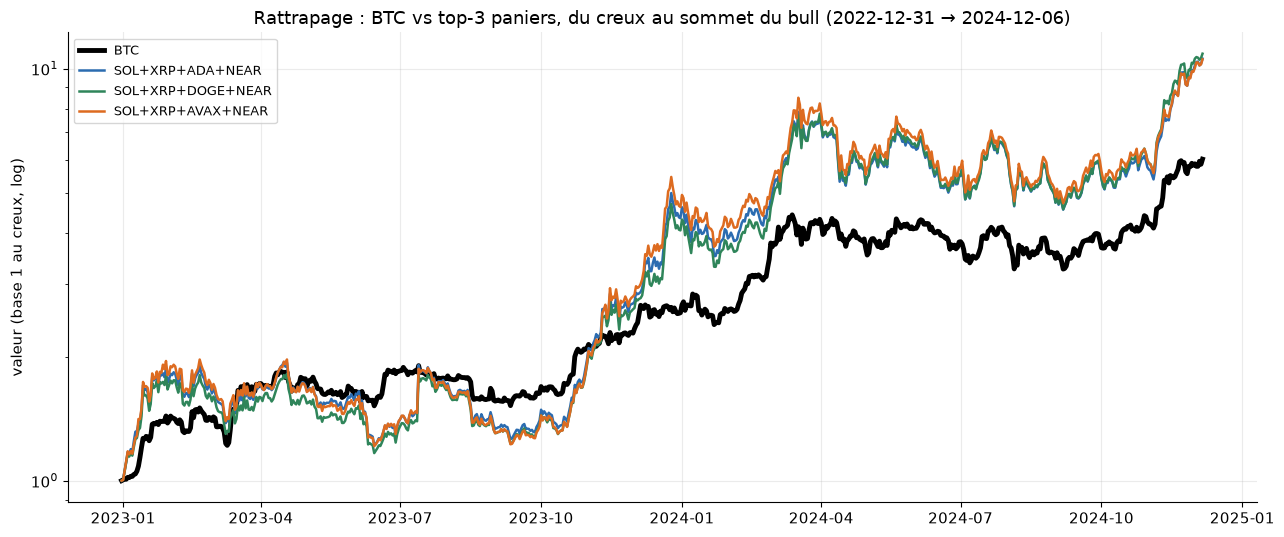

Multiple au SOMMET du bull depuis le creux — BTC : ×6.0
Panier               mult_final   vs_BTC   dépasse BTC après
  SOL+XRP+ADA+NEAR     × 10.6   +  75%        1 j  (plus vite)
  SOL+XRP+DOGE+NEAR    × 10.9   +  80%        2 j  (plus vite)
  SOL+XRP+AVAX+NEAR    × 10.5   +  75%        2 j  (plus vite)


In [16]:
top3 = bp.head(3)["panier"].tolist()
btc_n = btc.loc[trough:peak] / btc.loc[trough]           # creux → sommet du bull
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(btc_n.index, btc_n.values, color="black", lw=3.5, label="BTC")
rows_ll = []
for panier, col in zip(top3, ["#2b6cb0", "#2f855a", "#dd6b20"]):
    coins = [c + "USDT" for c in panier.split("+")]
    bh = (PXf[coins].loc[trough:peak] / PXf[coins].loc[trough].values).mean(axis=1)   # buy&hold équipondéré
    ax.plot(bh.index, bh.values, color=col, lw=1.8, label=panier)
    ahead = bh > btc_n.reindex(bh.index)
    over_date = ahead[ahead].index[0] if ahead.any() else None
    days_over = (over_date - trough).days if over_date is not None else None
    rows_ll.append((panier, bh.iloc[-1], btc_n.iloc[-1], days_over))
ax.set_yscale("log"); ax.set_ylabel("valeur (base 1 au creux, log)")
ax.set_title(f"Rattrapage : BTC vs top-3 paniers, du creux au sommet du bull ({trough.date()} → {peak.date()})")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print(f"Multiple au SOMMET du bull depuis le creux — BTC : ×{btc_n.iloc[-1]:.1f}")
print("Panier               mult_final   vs_BTC   dépasse BTC après")
for p, m, mb, d in rows_ll:
    verdict = "plus vite" if d is not None and d < 30 else ("rattrape puis dépasse" if d else "jamais")
    print(f"  {p:20s} ×{m:5.1f}   {'+' if m>mb else ''}{(m/mb-1)*100:4.0f}%   "
          f"{str(d)+' j' if d is not None else 'jamais':>8s}  ({verdict})")

### ⚠️ Le piège : « les alts battent BTC » dépend d'OÙ tu mesures

Le rattrapage ci-dessus est mesuré **du creux au sommet** — la fenêtre la plus flatteuse pour les alts.
Mais **les alts chutent plus fort que BTC** (en 2022 **et** en 2025-26). Donc selon le point de départ/arrivée,
la réponse **s'inverse**. Regarde le même panier vs BTC vs l'alt-index selon 4 cadrages :

cadrage                             BTC   panier  alt-index  gagnant
  Début 2022 → Sommet bull       × 2.1  ×  1.4   ×   0.9   BTC
  Début 2022 → Aujourd'hui       × 1.3  ×  0.5   ×   0.2   BTC
  Creux bear → Sommet bull       × 6.0  × 10.6   ×   4.4   PANIER
  Creux bear → Aujourd'hui       × 3.9  ×  3.3   ×   0.9   BTC


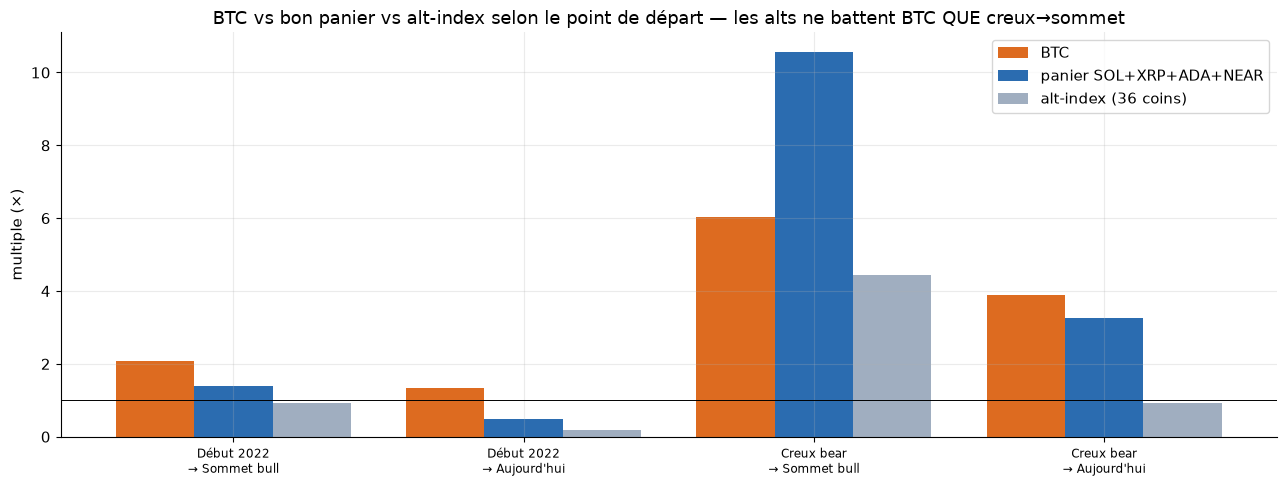

In [17]:
coins_top = [c + "USDT" for c in top3[0].split("+")]
refs = {"Début 2022": PXf.index[0], "Creux bear": trough}
ends = {"→ Sommet bull": peak, "→ Aujourd'hui": PXf.index[-1]}
scen, bB, bP, bA = [], [], [], []
for rl, s in refs.items():
    for el, e in ends.items():
        scen.append(f"{rl}\n{el}")
        bB.append(float(btc[e] / btc[s]))
        bP.append(float((PXf.loc[e, coins_top] / PXf.loc[s, coins_top]).mean()))
        bA.append(float(alt_idx[e] / alt_idx[s]))
print(f"{'cadrage':32s} {'BTC':>6s} {'panier':>8s} {'alt-index':>10s}  gagnant")
for sc, b, p, a in zip([s.replace(chr(10), ' ') for s in scen], bB, bP, bA):
    print(f"  {sc:30s} ×{b:4.1f}  ×{p:5.1f}   ×{a:6.1f}   {'PANIER' if p > b else 'BTC'}")

x = np.arange(len(scen)); w = 0.27
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, bB, w, label="BTC", color="#dd6b20")
ax.bar(x, bP, w, label=f"panier {top3[0]}", color="#2b6cb0")
ax.bar(x + w, bA, w, label="alt-index (36 coins)", color="#a0aec0")
ax.axhline(1, color="k", lw=.7)
ax.set_xticks(x); ax.set_xticklabels(scen, fontsize=8.5); ax.set_ylabel("multiple (×)")
ax.set_title("BTC vs bon panier vs alt-index selon le point de départ — les alts ne battent BTC QUE creux→sommet")
ax.legend(); plt.tight_layout(); plt.show()

**La vérité, honnête** :
- **BTC mène le retournement** (~40 j avant les alts) — ça, c'est vrai, ton intuition est bonne.
- **MAIS les bonnes combins ne « rattrapent » BTC que dans UN seul cas** : acheté au **creux exact** ET
  vendu au **sommet exact** (×10.9 vs ×6.0). C'est un **timing parfait** que personne ne réalise.
- Dans **tous les cadrages réalistes**, **BTC gagne** :
  - Depuis le début du cycle (2022) → BTC ×2.1 vs panier ×1.8 (les alts ont chuté trop fort, trou plus profond).
  - En tenant jusqu'à aujourd'hui → BTC ×3.9 vs panier ×3.4 (les alts rendent tout dans le bear).
  - L'**alt-index** (tous les alts) est **écrasé partout** (×0.9, ×0.2).

> **Le fond du problème (la « dominance BTC »)** : *les alts montent PLUS que BTC depuis le fond, mais chutent
> PLUS fort partout ailleurs.* Sur un cycle réel, **BTC domine** — battre BTC avec des alts exige un timing
> quasi-parfait des DEUX bouts. Concrètement : BTC = le cœur/refuge ; les alts = un pari de haut de cycle à
> n'oser que si tu sais entrer près du creux **et** sortir avant la rechute.

# PARTIE VI — Robustesse des paramètres (plateaux vs pics)

**Optimiser = risquer l'overfitting.** La bonne façon : chercher des **plateaux** (une zone entière de valeurs
marche) et se méfier des **pics** isolés (chance). On balaie chaque paramètre (momentum + filtre de tendance),
en médiane sur les paniers. Un **pic** isolé = de la chance de calendrier ; un **plateau** = un vrai réglage.

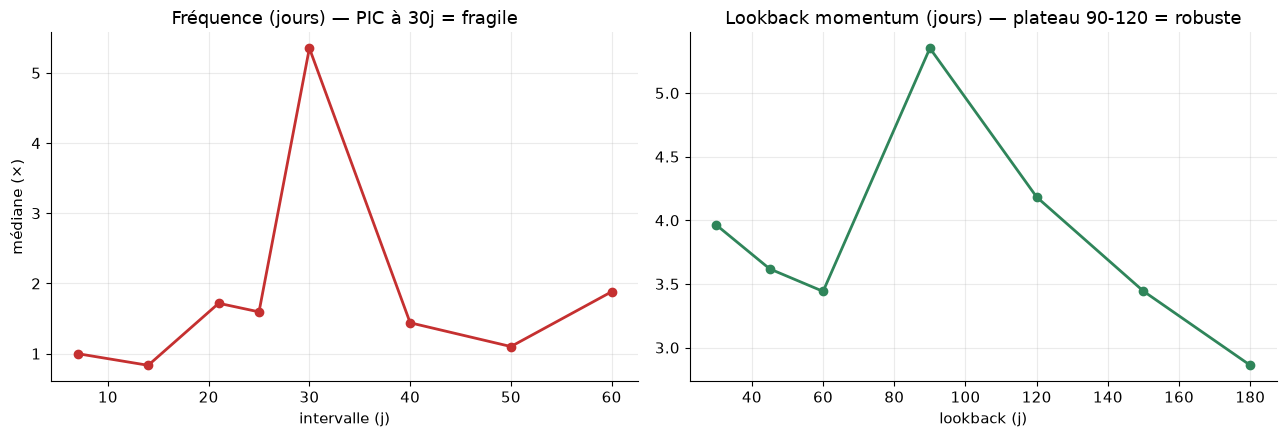

Fréquence : {'7j': np.float64(1.0), '14j': np.float64(0.8), '21j': np.float64(1.7), '25j': np.float64(1.6), '30j': np.float64(5.4), '40j': np.float64(1.4), '50j': np.float64(1.1), '60j': np.float64(1.9)}
Lookback  : {'30j': np.float64(4.0), '45j': np.float64(3.6), '60j': np.float64(3.4), '90j': np.float64(5.4), '120j': np.float64(4.2), '150j': np.float64(3.4), '180j': np.float64(2.9)}

→ Le pic isolé à 30j (voisins bien plus bas) = signal d'OVERFITTING : le chiffre exact n'est pas fiable.
→ Le lookback 90-120j forme un vrai PLATEAU = robuste.


In [18]:
def sweep_median(param, values, base):
    out = []
    for v in values:
        step = v if param == "step" else base["step"]
        lm = v if param == "lmom" else base["lmom"]
        vals = [equity_filtered(idx, w_maxsharpe, step, lm).iloc[-1] for idx in SAMPLE]
        out.append(np.median(vals))
    return out


steps = [7, 14, 21, 25, 30, 40, 50, 60]; lms = [30, 45, 60, 90, 120, 150, 180]
base = {"step": 30, "lmom": 90}
sw_step = sweep_median("step", steps, base)
sw_lmom = sweep_median("lmom", lms, base)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(steps, sw_step, "o-", color="#c53030", lw=2); axes[0].set_title("Fréquence (jours) — PIC à 30j = fragile")
axes[0].set_xlabel("intervalle (j)"); axes[0].set_ylabel("médiane (×)")
axes[1].plot(lms, sw_lmom, "o-", color="#2f855a", lw=2); axes[1].set_title("Lookback momentum (jours) — plateau 90-120 = robuste")
axes[1].set_xlabel("lookback (j)")
plt.tight_layout(); plt.show()
print("Fréquence :", {f"{s}j": round(v, 1) for s, v in zip(steps, sw_step)})
print("Lookback  :", {f"{l}j": round(v, 1) for l, v in zip(lms, sw_lmom)})
print("\n→ Le pic isolé à 30j (voisins bien plus bas) = signal d'OVERFITTING : le chiffre exact n'est pas fiable.")
print("→ Le lookback 90-120j forme un vrai PLATEAU = robuste.")

# PARTIE VII — Simulation 4 000 € & pratique

> ⚠️ **Rappel** : la simulation ci-dessous est sur **le panier démo (un seul exemple)**. Sur ce panier,
> Max-Sharpe finit **dernier** (le momentum s'y fait whipsawer) — **à l'opposé** de sa **meilleure médiane**
> sur 495 paniers (Partie V). C'est sa **variance élevée**, pas une contradiction. Le classement *fiable* est
> celui de la **distribution (Partie V)** ; ceci n'est qu'un cas concret parmi des centaines.

Simulation de 4 000 € sur consolidation+bull (rebal mensuel, net de coûts) :

  Drift              4000€ →    36556€  (×9.1, pire chute -44%)
  Equal              4000€ →    33062€  (×8.3, pire chute -48%)
  InvVol             4000€ →    29459€  (×7.4, pire chute -47%)
  RiskPar            4000€ →    28806€  (×7.2, pire chute -47%)
  HRP                4000€ →    24712€  (×6.2, pire chute -46%)
  HODL_BTC           4000€ →    24118€  (×6.0, pire chute -26%)
  MinVar             4000€ →    14293€  (×3.6, pire chute -48%)
  MaxSharpe          4000€ →    12638€  (×3.2, pire chute -50%)


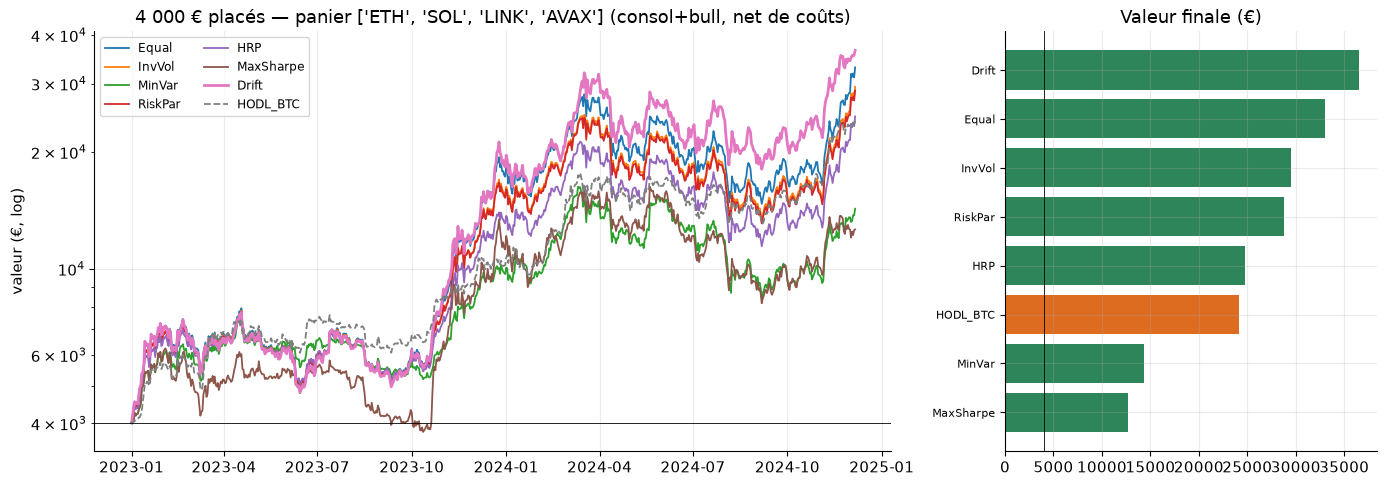


Timing de sortie (drift du panier démo) — vendre X semaines après le sommet du bull :
   sommet +  0 sem : tu gardes 36556€
   sommet +  2 sem : tu gardes 30262€
   sommet +  4 sem : tu gardes 32941€
   sommet +  8 sem : tu gardes 33679€
   sommet + 12 sem : tu gardes 21442€
   sommet + 20 sem : tu gardes 21330€
   sommet + 26 sem : tu gardes 21132€


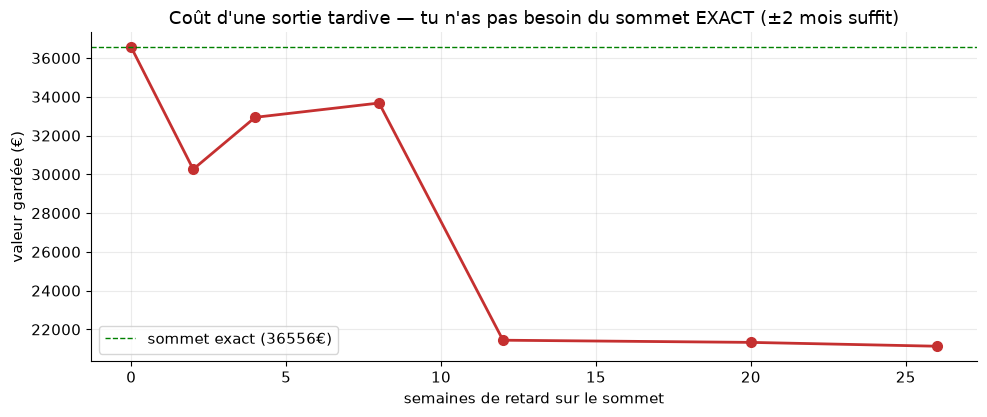

In [19]:
INIT = 4000.0
print("Simulation de 4 000 € sur consolidation+bull (rebal mensuel, net de coûts) :\n")
sim4k = {}
for m, fn in METHODS.items():
    eq = equity_fullinvest(didx, fn, 30, TP, PK) * INIT
    sim4k[m] = eq
sim4k["Drift"] = equity_drift(didx, TP, PK) * INIT
sim4k["HODL_BTC"] = pd.Series(BTCv[TP:PK + 1] / BTCv[TP], index=PXf.index[TP:PK + 1]) * INIT
res4k = pd.DataFrame({k: dict(final=v.iloc[-1], maxdd=(v / v.cummax() - 1).min()) for k, v in sim4k.items()}).T
res4k = res4k.sort_values("final", ascending=False)
for k, row in res4k.iterrows():
    print(f"  {k:18s} 4000€ → {row['final']:8.0f}€  (×{row['final']/INIT:.1f}, pire chute {row['maxdd']*100:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[3, 1.4])
for name, eq in sim4k.items():
    st = "--" if name == "HODL_BTC" else "-"
    axes[0].plot(eq.index, eq.values, st, lw=2 if name == "Drift" else 1.3, label=name)
axes[0].axhline(INIT, color="k", lw=.6); axes[0].set_yscale("log")
axes[0].set_title(f"4 000 € placés — panier {[a[:-4] for a in DEMO]} (consol+bull, net de coûts)")
axes[0].set_ylabel("valeur (€, log)"); axes[0].legend(fontsize=8.5, ncol=2)
order = res4k.index.tolist()[::-1]
axes[1].barh(range(len(order)), [res4k.loc[k, "final"] for k in order],
             color=["#2f855a" if k != "HODL_BTC" else "#dd6b20" for k in order])
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels(order, fontsize=8)
axes[1].axvline(INIT, color="k", lw=.6); axes[1].set_title("Valeur finale (€)")
plt.tight_layout(); plt.show()

# timing de sortie : vendre X semaines après le sommet
driftv = equity_drift(didx, TP, END) * INIT
wks = [0, 2, 4, 8, 12, 20, 26]
kept = [driftv.iloc[driftv.index.get_indexer([PXf.index[min(PK + wk * 7, END)]], method="nearest")[0]] for wk in wks]
print("\nTiming de sortie (drift du panier démo) — vendre X semaines après le sommet du bull :")
for wk, v in zip(wks, kept):
    print(f"   sommet + {wk:2d} sem : tu gardes {v:.0f}€")
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.plot(wks, kept, "o-", color="#c53030", lw=2, ms=7)
ax.axhline(kept[0], color="g", ls="--", lw=1, label=f"sommet exact ({kept[0]:.0f}€)")
ax.set_xlabel("semaines de retard sur le sommet"); ax.set_ylabel("valeur gardée (€)")
ax.set_title("Coût d'une sortie tardive — tu n'as pas besoin du sommet EXACT (±2 mois suffit)")
ax.legend(); plt.tight_layout(); plt.show()

## VII.2 — Combien de lignes tenir ? (opérationnel)

On **scanne** les 12 coins mais on n'en **détient** qu'une poignée : les **top-K par momentum**. Combien faut-il
en tenir pour capter l'edge, et combien d'ordres ça fait ? *(Tenir 8 sur 12 = léger, ~3 ordres/rebal.)*

Tenir le TOP-K momentum (scan 12 coins) — consol+bull, 4 000 € :
   top-3  : 4000€ →   45995€  (×11.5, ~3.9 ordres/rebal)
   top-5  : 4000€ →   31496€  (×7.9, ~5.7 ordres/rebal)
   top-8  : 4000€ →   29244€  (×7.3, ~7.7 ordres/rebal)
   top-12 : 4000€ →   24744€  (×6.2, ~7.5 ordres/rebal)


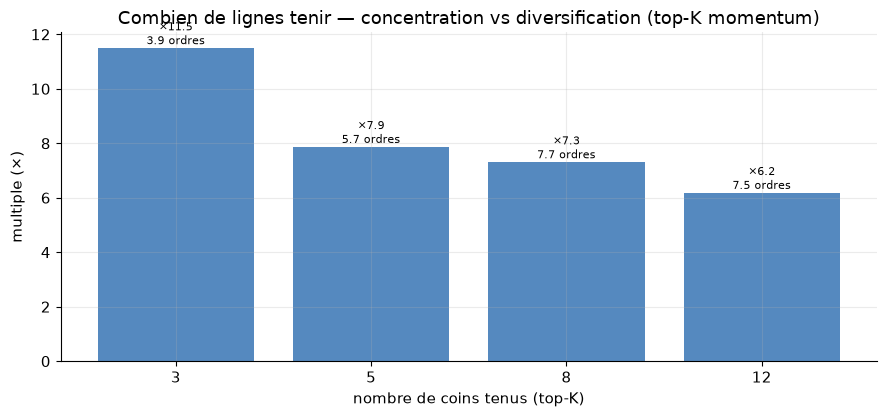

→ 3-5 lignes = plus de rendement mais concentré (loterie) ; 8-12 = robuste, ~3-4 ordres/rebal, gérable à la main.


In [20]:
def topk_momentum(univ_idx, K, step=30, start=TP, end=PK):
    Ru = RA[:, univ_idx]; Pu = PA[:, univ_idx]; nU = len(univ_idx)
    pos = list(range(start, end, step)); hold = np.zeros(nU); cash = 1.0; npos = []; orders = []
    for k, p in enumerate(pos):
        tot = hold.sum() + cash
        w = np.zeros(nU); w[np.argsort(Pu[p] / Pu[p - LMOM] - 1)[-K:]] = 1.0 / K
        tgt = w * tot; orders.append(int(np.sum(np.abs(tgt - hold) > 0.005 * tot)))
        cash = tot - tgt.sum() - FEE * np.abs(tgt - hold).sum(); hold = tgt; npos.append(K)
        nx = pos[k + 1] if k + 1 < len(pos) else end
        for t in range(p + 1, nx + 1): hold = hold * (1 + Ru[t])
    return (hold.sum() + cash), np.mean(orders)


print("Tenir le TOP-K momentum (scan 12 coins) — consol+bull, 4 000 € :")
kres = []
for K in [3, 5, 8, 12]:
    mult, ords = topk_momentum(U12i, K)
    kres.append((K, mult, ords)); print(f"   top-{K:<2d} : 4000€ → {mult*4000:7.0f}€  (×{mult:.1f}, ~{ords:.1f} ordres/rebal)")
fig, ax = plt.subplots(figsize=(9, 4.3))
Ks = [r[0] for r in kres]
ax.bar([str(k) for k in Ks], [r[1] for r in kres], color="#2b6cb0", alpha=0.8)
for k, m, o in kres: ax.annotate(f"×{m:.1f}\n{o:.1f} ordres", (str(k), m), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("nombre de coins tenus (top-K)"); ax.set_ylabel("multiple (×)")
ax.set_title("Combien de lignes tenir — concentration vs diversification (top-K momentum)")
plt.tight_layout(); plt.show()
print("→ 3-5 lignes = plus de rendement mais concentré (loterie) ; 8-12 = robuste, ~3-4 ordres/rebal, gérable à la main.")

## VII.3 — ⭐ Le VRAI test : sélection dynamique par momentum parmi les 37

Jusqu'ici on testait des **paniers fixes de 4 coins** — mais ça suppose de **connaître** les bons coins à
l'avance. La stratégie *réaliste*, c'est de **scanner les 37 coins** et de laisser le **momentum choisir** le
top-K du moment (sans rien savoir du futur). On le teste sur la même fenêtre consol+bull, contre BTC,
l'équipondéré-37, et — pour référence — le **meilleur panier de 4 en hindsight** (qui, lui, « triche »).

Sélection dynamique momentum PARMI 37 coins — consol+bull, 4 000 € :
   top-3  /37 : 4000€ →   16002€  (×4.0, ~4.4 ordres/rebal)
   top-5  /37 : 4000€ →   21087€  (×5.3, ~6.5 ordres/rebal)
   top-8  /37 : 4000€ →   20642€  (×5.2, ~10.1 ordres/rebal)
   top-12 /37 : 4000€ →   18446€  (×4.6, ~12.9 ordres/rebal)
   top-20 /37 : 4000€ →   18845€  (×4.7, ~16.4 ordres/rebal)
   Buy&Hold BTC : ×6.0   |   Equal-weight 37 : ×4.5   |   meilleur panier-4 (HINDSIGHT) : ×25.5


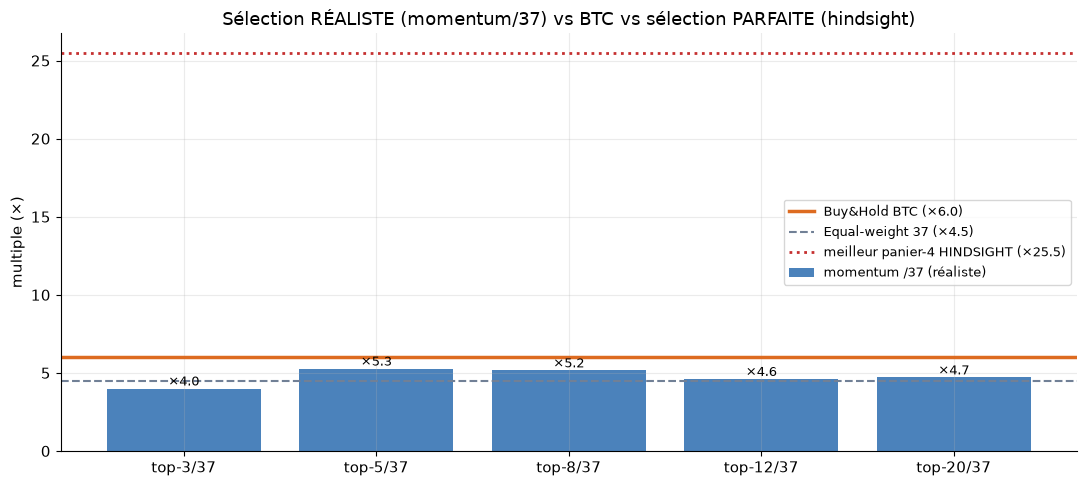

In [21]:
ALL37 = list(range(len(cols_all)))
btc_mult = BTCv[PK] / BTCv[TP]
ew37 = (1 + PXf.pct_change().fillna(0).mean(axis=1)).cumprod()
ew37_mult = ew37.iloc[PK] / ew37.iloc[TP]
best4_mult = bp["mult"].iloc[0]      # meilleur panier de 4 (hindsight)
print("Sélection dynamique momentum PARMI 37 coins — consol+bull, 4 000 € :")
k37 = []
for K in [3, 5, 8, 12, 20]:
    m, o = topk_momentum(ALL37, K)
    k37.append((K, m)); print(f"   top-{K:<2d} /37 : 4000€ → {m*4000:7.0f}€  (×{m:.1f}, ~{o:.1f} ordres/rebal)")
print(f"   {'Buy&Hold BTC':13s}: ×{btc_mult:.1f}   |   Equal-weight 37 : ×{ew37_mult:.1f}   |   "
      f"meilleur panier-4 (HINDSIGHT) : ×{best4_mult:.1f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([f"top-{k}/37" for k, _ in k37], [m for _, m in k37], color="#2b6cb0", alpha=0.85, label="momentum /37 (réaliste)")
ax.axhline(btc_mult, color="#dd6b20", lw=2.5, ls="-", label=f"Buy&Hold BTC (×{btc_mult:.1f})")
ax.axhline(ew37_mult, color="#718096", lw=1.5, ls="--", label=f"Equal-weight 37 (×{ew37_mult:.1f})")
ax.axhline(best4_mult, color="#c53030", lw=2, ls=":", label=f"meilleur panier-4 HINDSIGHT (×{best4_mult:.1f})")
for k, m in k37: ax.annotate(f"×{m:.1f}", (f"top-{k}/37", m), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("multiple (×)")
ax.set_title("Sélection RÉALISTE (momentum/37) vs BTC vs sélection PARFAITE (hindsight)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

**Le résultat qui remet tout à sa place** :
- La sélection **réaliste** (momentum sur 37, sans connaître le futur) fait **~×5** → elle bat l'équipondéré
  des 37 (×4.5), **mais NE bat PAS BTC (×6.0)** sur le bull.
- Elle est **très loin** du meilleur panier de 4 en *hindsight* (×25).
- **L'écart ×25 → ×5 = le coût de ne pas connaître le futur.** Le fameux panier à ×25 n'était captable
  qu'en **connaissant les gagnants à l'avance** ; le momentum n'en récupère qu'une fraction.

> **Conclusion honnête** : même en scannant 37 coins et en laissant le momentum choisir, tu ne bats pas un
> simple **Buy & Hold BTC** sur le bull. La sélection systématique aide (vs équipondéré) mais **ne suffit pas**
> à transformer les alts en machine à battre BTC. Le ×25, c'était de la chance rétrospective.

# PARTIE VIII — Synthèse honnête

## Ce qui est ROBUSTE (vrai sur des centaines de paniers)
1. **En bull, être long rapporte gros (×5-8)** — c'est du **bêta** (exposition marché), pas du skill.
2. **La SÉLECTION domine** : l'écart entre paniers (×2.5 → ×11) écrase l'écart entre méthodes. *Quels coins*
   compte bien plus que *comment pondérer*.
3. **Ne rebalance pas trop souvent** : hebdo/bi-hebdo font whipsawer le momentum. Mensuel/45j/60j = correct.
4. **Le momentum a une valeur défensive** (rotation hors des perdants) qui apparaît sur plusieurs phases.
5. **Les méthodes « risk-based » (min-var, HRP)** sous-pondèrent le gagnant volatil → elles *perdent* en bull.
6. **Dominance BTC** : les alts montent PLUS que BTC **depuis le creux**, mais **chutent PLUS fort partout
   ailleurs**. Sur un cycle réel (début-2022, ou jusqu'à aujourd'hui), **BTC bat les bonnes combins d'alts**.
   Les alts ne gagnent qu'avec un **timing quasi-parfait** (creux exact → sommet exact). BTC mène aussi le
   **retournement** (~40 j avant les alts).

## Ce qui est du BRUIT (ne pas s'y fier)
- Le classement exact des méthodes (il s'inverse selon le panier / la fenêtre).
- Les chiffres de paramètres « optimaux » qui sont des **pics** (ex. le ×5.6 à pile 30j).
- Toute « meilleure combinaison » choisie *a posteriori* (= juste celle avec le pump de SOL).

## Les 3 décisions, verdict
| Décision | Importance | Ce qui marche |
|---|---|---|
| **SÉLECTION** (quels coins) | 🔥🔥🔥 dominante | coins à fort momentum ; élargir l'univers ; momentum de sélection |
| **TIMING** (quand sortir) | 🔥🔥 clé | filtre de tendance / discipline de sortie avant le bear |
| **PONDÉRATION** (combien) | 🔥 secondaire | equal-weight ou momentum, rebalance mensuel — inutile de sur-optimiser |

## Recommandation pratique (pour un capital réel)
- **Univers** : élargir à 20-30 cryptos liquides (le momentum de sélection a besoin de largeur).
- **Composition** : simple — equal-weight ou top-momentum, rebalancé **mensuel** (jamais hebdo).
- **Risque** : garder BTC comme cœur/refuge ; **sortir avant/pendant le bear** (là est le vrai edge, et il
  dépend de ta discipline, pas d'un paramètre à optimiser).
- **Limites** : un seul cycle de données, peu d'actifs → aucune de ces conclusions n'est une garantie.
  Avant tout capital réel : **paper-trading**, et méfiance envers tout backtest trop beau.

> **La leçon centrale.** La complexité (HRP, Black-Litterman, Markowitz, optimisation de paramètres) ne bat
> pas le simple ici — elle sur-ajuste. Le vrai edge n'est pas dans une formule de pondération, il est dans
> **choisir les bons coins** et **savoir sortir**. Le reste est du bêta et du bruit.